In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 31 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 24.76 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149373 entries, 0 to 149372
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 491.2+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 41156

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35534    86.34            5622
                        recoveries_elo_p90sq_3      35534    86.34            5622
                               tackles_p90sq_3      35534    86.34            5622
                           tackles_elo_p90sq_3      35534    86.34            5622
                                   cbi_p90sq_3      35534    86.34            5622
                               cbi_elo_p90sq_3      35534    86.34            5622
                        defensive_cont_p90sq_3      35534    86.34            5622
                    defensive_cont_elo_p90sq_3      35534    86.34            5622
                               tackles_p90sq_5      35486    86.22            5670
                           tackles_elo_p90sq_5      35486    86

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132403,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132405,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132407,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132409,Bukayo Saka,24.0,0.0,Leeds,0.356240
132411,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132371,Bukayo Saka,26.0,1.0,Brentford,0.356240
132391,Bukayo Saka,27.0,5.0,Spurs,0.353169
132413,Bukayo Saka,28.0,2.0,Chelsea,0.353025
132414,Bukayo Saka,29.0,9.0,Brighton,0.350034
132415,Bukayo Saka,30.0,3.0,Everton,0.347214


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2576/7635

Training Set Performance:
R² Score: 0.8338
RMSE: 13.3766
MAE: 11.0229

Test Set Performance:
R² Score: 0.3093
RMSE: 27.3271
MAE: 22.0793

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.170577
   opp_team_elo_p90sq_3    0.092380
          minutes_elo_3    0.053587
   opp_team_elo_p90sq_5    0.043597
       team_elo_p90sq_3    0.031162
       team_elo_p90sq_5    0.016026
      team_elo_p90sq_at    0.013333
  opp_team_elo_p90sq_at    0.012750
  clean_sheets_p90sq_at    0.011771
           bps_p90sq_at    0.010493
goals_conceded_p90sq_at    0.009026
  opp_team_elo_p90sq_10    0.008662
         opp_team_elo_5    0.008624
               team_elo    0.008616
               elo_diff    0.007923
      team_elo_p90sq_10    0.007812
           opp_team_elo    0.007796
        xg_over_g_ratio    0.006520
opp_team_elo_elo_p90_10    0.005720
        opp_team_elo_10    0.005477


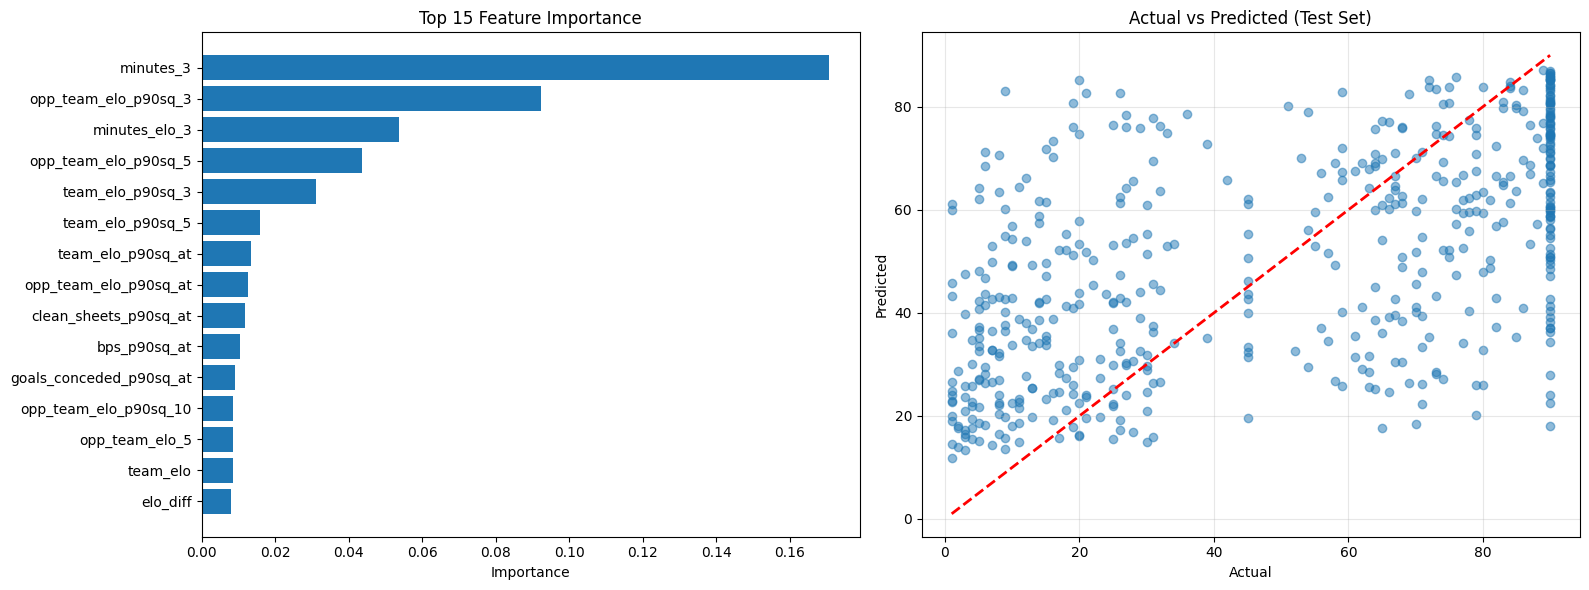

Cleaned df size: 8942/28491

Training Set Performance:
R² Score: 0.6711
RMSE: 18.4289
MAE: 15.1150

Test Set Performance:
R² Score: 0.2839
RMSE: 26.9830
MAE: 21.9138

Top 20 Feature Importances:
              feature  importance
            minutes_3    0.376523
 opp_team_elo_p90sq_5    0.022160
 opp_team_elo_p90sq_3    0.017776
opp_team_elo_p90sq_10    0.015327
               bps_10    0.013799
     team_elo_p90sq_5    0.013544
           minutes_10    0.010893
        minutes_elo_3    0.010469
    minutes_elo_p90_5    0.008797
      xg_over_g_ratio    0.008752
                bps_3    0.007487
         opp_team_elo    0.007336
            minutes_5    0.006994
     team_elo_p90sq_3    0.006942
clean_sheets_p90sq_at    0.006848
       minutes_elo_10    0.006600
opp_team_elo_p90sq_at    0.006530
    team_elo_p90sq_at    0.006065
       opp_team_elo_3    0.006027
      opp_team_elo_10    0.005513


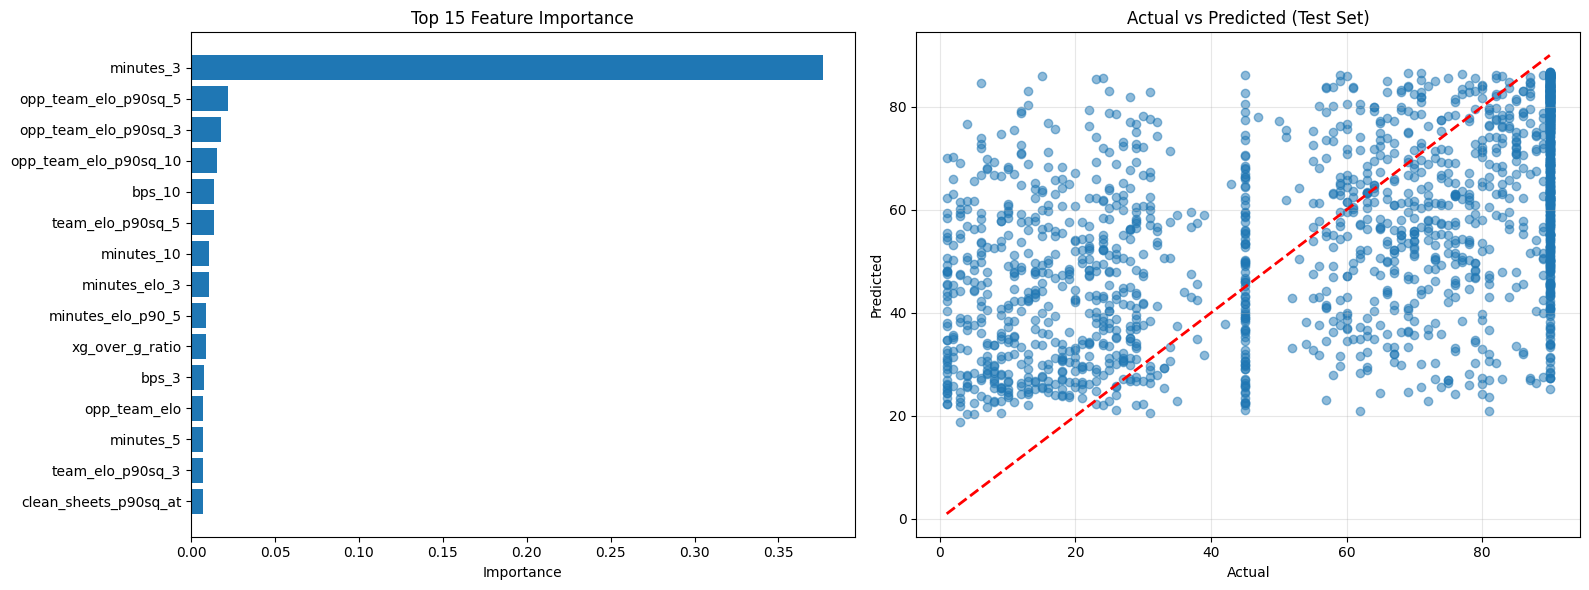

Cleaned df size: 5511/20533

Training Set Performance:
R² Score: 0.6818
RMSE: 16.6623
MAE: 12.4781

Test Set Performance:
R² Score: 0.1910
RMSE: 25.3675
MAE: 18.4900

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.126508
        team_elo_p90sq_3    0.075032
    opp_team_elo_p90sq_3    0.057084
   opp_team_elo_p90sq_10    0.018961
opp_team_elo_elo_p90sq_3    0.016370
           minutes_elo_3    0.013948
       team_elo_p90sq_10    0.011784
          opp_team_elo_3    0.011318
         xg_over_g_ratio    0.011126
         opp_team_elo_10    0.010912
       xassists_p90sq_at    0.009792
 goals_conceded_p90sq_at    0.009218
            opp_team_elo    0.009214
                elo_diff    0.008951
          bonus_p90sq_at    0.008843
xgoals_conceded_p90sq_at    0.008669
          opp_team_elo_5    0.008480
   opp_team_elo_p90sq_at    0.007947
            bps_p90sq_at    0.007914
   total_points_p90sq_at    0.007818


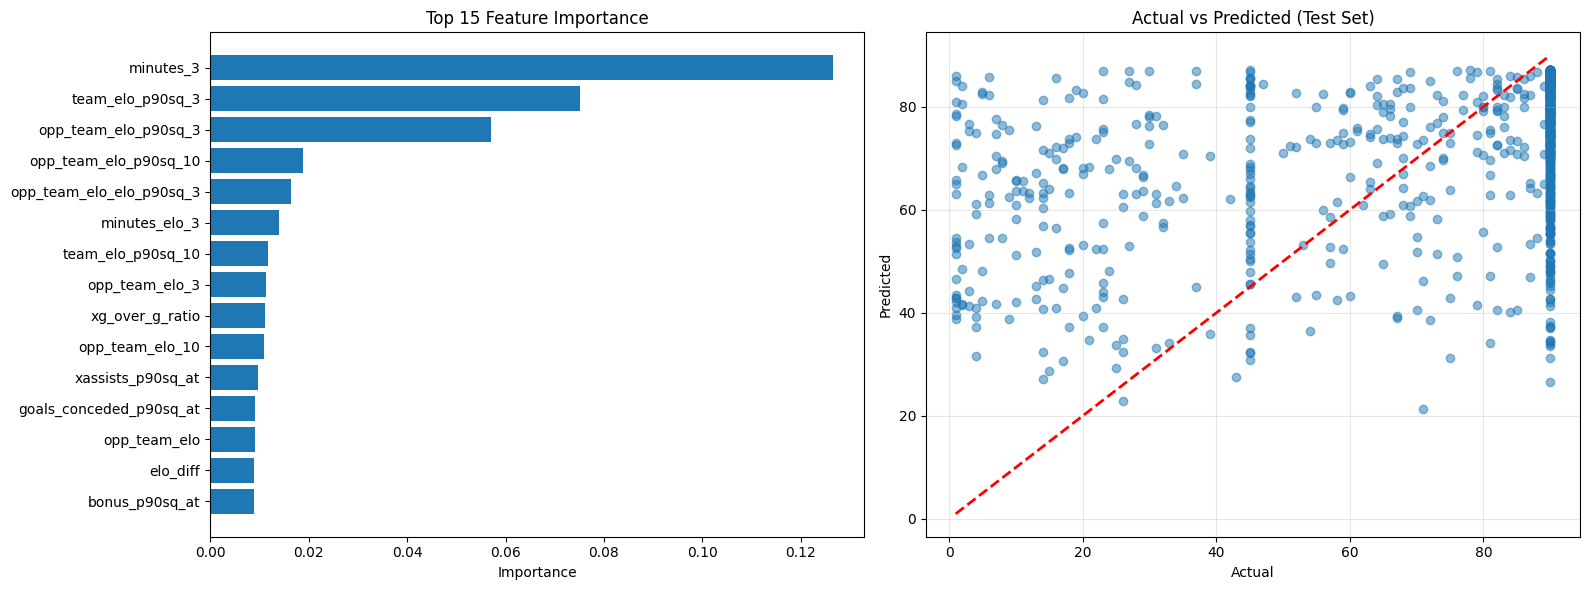

Cleaned df size: 3968/4236

Training Set Performance:
R² Score: 0.7233
RMSE: 2.7363
MAE: 0.5704

Test Set Performance:
R² Score: -0.1318
RMSE: 4.9241
MAE: 1.0261

Top 20 Feature Importances:
              feature  importance
       team_elo_elo_3    0.043082
opp_team_elo_p90sq_at    0.039589
         opp_team_elo    0.037823
       saves_p90sq_10    0.031539
         bps_p90sq_10    0.029578
          bps_p90sq_3    0.025032
total_points_p90sq_10    0.021927
         bps_p90sq_at    0.020528
 opp_team_elo_p90sq_5    0.018507
    team_elo_p90sq_at    0.017276
       opp_team_elo_5    0.017240
    saves_elo_p90sq_3    0.016632
  minutes_elo_p90sq_3    0.014832
       opp_team_elo_3    0.014316
       saves_p90sq_at    0.014213
               bps_10    0.013845
      opp_team_elo_10    0.012753
          bps_p90sq_5    0.012611
   team_elo_elo_p90_3    0.012399
        saves_p90sq_3    0.012181


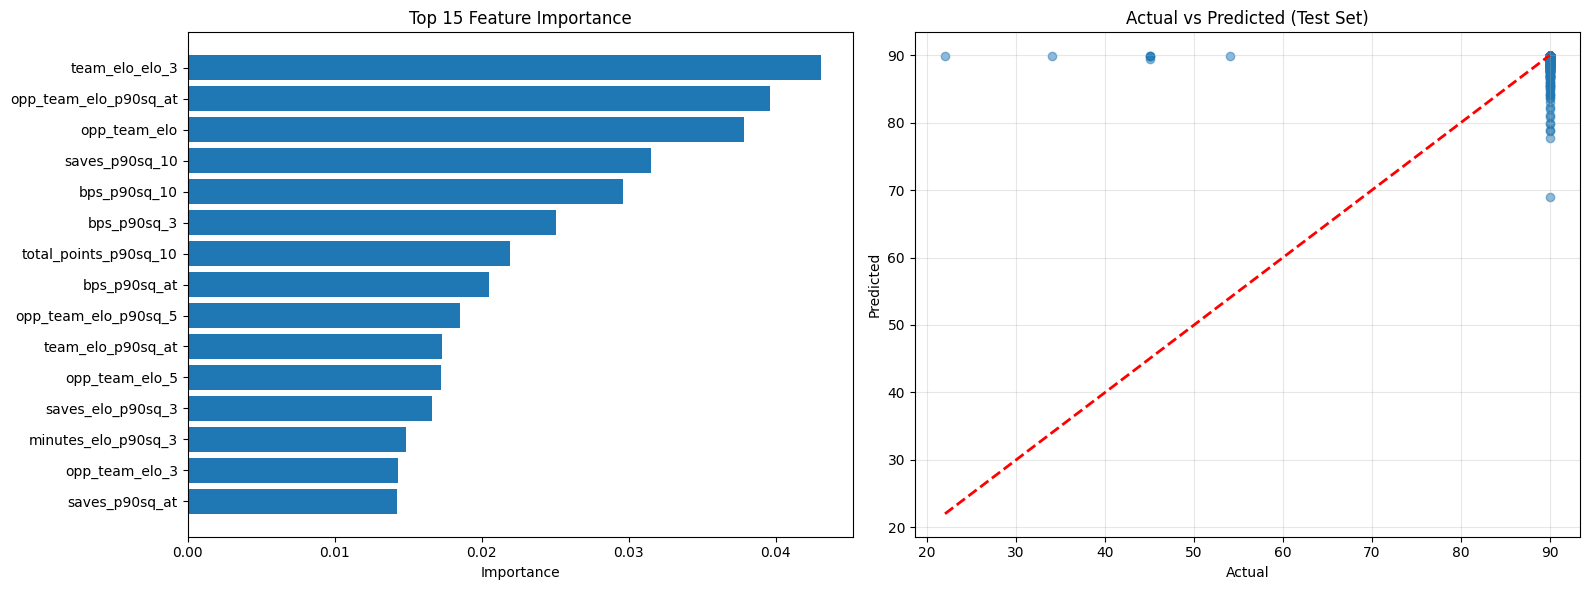

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2666/4380

Training Set Performance:
R² Score: 0.6091
RMSE: 0.2429
MAE: 0.1956

Test Set Performance:
R² Score: 0.0074
RMSE: 0.3909
MAE: 0.2954

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.036255
    goals_scored_p90sq_at    0.034578
          xg_over_g_ratio    0.024807
           bonus_p90sq_at    0.024479
             opp_team_elo    0.018950
           opp_team_elo_5    0.014897
           opp_team_elo_3    0.014554
     opp_team_elo_p90sq_5    0.013995
          opp_team_elo_10    0.013926
      total_points_p90_10    0.013016
             bps_p90sq_at    0.012658
  goals_conceded_p90sq_at    0.011814
            minutes_elo_3    0.011327
        team_elo_p90sq_at    0.010974
         team_elo_p90sq_5    0.010861
         team_elo_p90sq_3    0.010789
    opp_team_elo_p90sq_10    0.010676
    opp_team_elo_p90sq_at    0.010631
total_points_elo_p90sq_10    0.010578
    

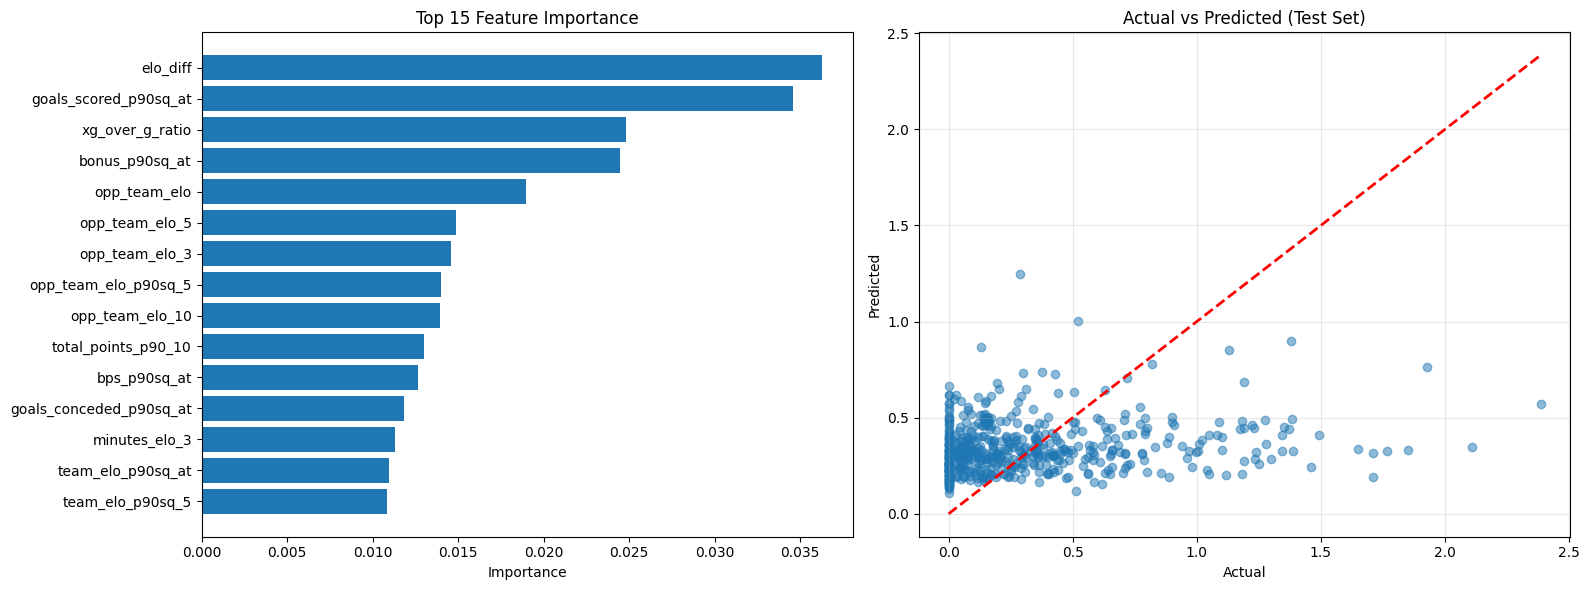

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 12300/18722

Training Set Performance:
R² Score: 0.3802
RMSE: 0.1737
MAE: 0.1177

Test Set Performance:
R² Score: 0.0765
RMSE: 0.2154
MAE: 0.1381

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.156818
             opp_team_elo    0.031406
           bonus_p90sq_at    0.031069
                 elo_diff    0.019502
          opp_team_elo_10    0.017845
    clean_sheets_p90sq_at    0.017701
             bps_p90sq_10    0.015102
    opp_team_elo_p90sq_at    0.014510
           opp_team_elo_3    0.013652
           opp_team_elo_5    0.013226
  goals_conceded_p90sq_at    0.011249
             bps_p90sq_at    0.010617
        team_elo_p90sq_at    0.010509
      goals_scored_elo_10    0.010139
      total_points_elo_10    0.009305
total_points_elo_p90sq_10    0.009178
    goals_conceded_elo_10    0.009123
     opp_team_elo_p90sq_5    0.009043
    clean_sheets_p90sq_10    0.008965
  

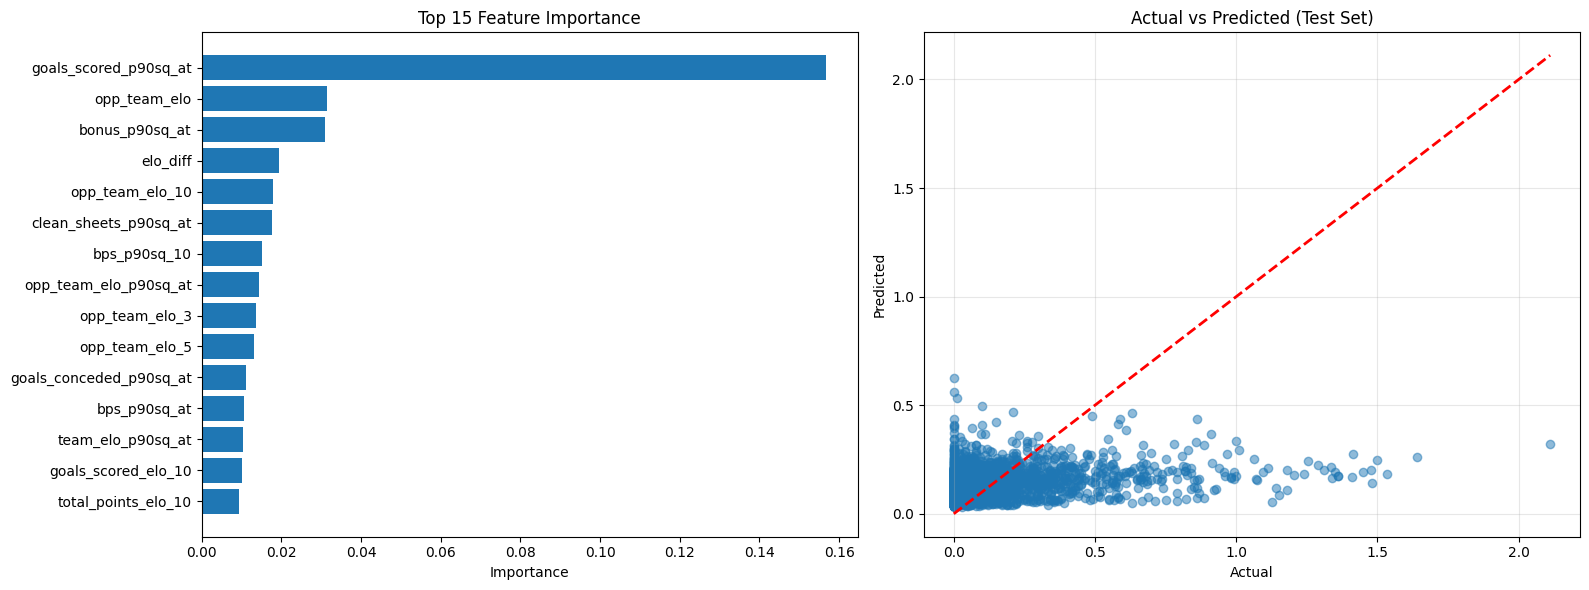

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10542/16752

Training Set Performance:
R² Score: 0.2638
RMSE: 0.0929
MAE: 0.0559

Test Set Performance:
R² Score: -0.0424
RMSE: 0.1014
MAE: 0.0604

Top 20 Feature Importances:
                    feature  importance
             opp_team_elo_3    0.044633
               opp_team_elo    0.035846
      goals_scored_p90sq_at    0.034891
          team_elo_p90sq_at    0.022209
    goals_conceded_p90sq_at    0.020784
               bps_p90sq_at    0.017986
     opp_team_elo_elo_p90_5    0.017852
      goals_conceded_elo_10    0.017449
         total_points_elo_5    0.016831
      total_points_p90sq_at    0.015917
      opp_team_elo_p90sq_10    0.015101
             opp_team_elo_5    0.014619
        goals_scored_elo_10    0.013901
  goals_conceded_elo_p90_10    0.013538
                   elo_diff    0.013122
goals_conceded_elo_p90sq_10    0.012344
                team_elo_10    0.012297
      total_points_p90sq_10    0.012046
 

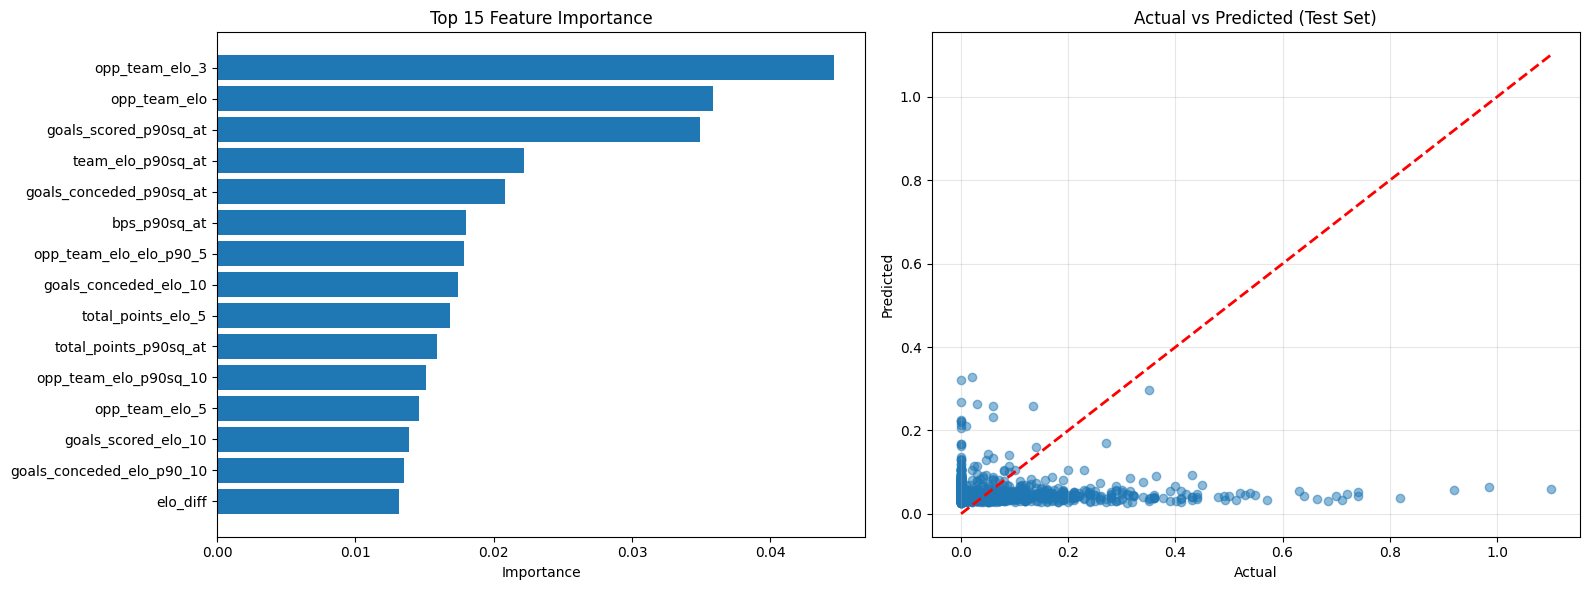

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2863/4667

Training Set Performance:
R² Score: 0.5377
RMSE: 0.0798
MAE: 0.0538

Test Set Performance:
R² Score: 0.0321
RMSE: 0.1272
MAE: 0.0781

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.040588
                elo_diff    0.030458
         xg_over_g_ratio    0.028039
          opp_team_elo_3    0.022335
          opp_team_elo_5    0.019000
    total_points_p90sq_3    0.018709
       minutes_elo_p90_5    0.016897
         bps_elo_p90sq_3    0.015053
       minutes_elo_p90_3    0.014906
              bps_elo_10    0.013936
total_points_elo_p90sq_3    0.013630
           minutes_elo_3    0.013329
         opp_team_elo_10    0.013150
 opp_team_elo_elo_p90_10    0.012340
            bonus_elo_10    0.012043
      minutes_elo_p90_10    0.011743
 goals_conceded_p90sq_at    0.011206
         bps_elo_p90sq_5    0.010866
           bps_elo_p90_5    0.010863
      team_elo_elo_p90

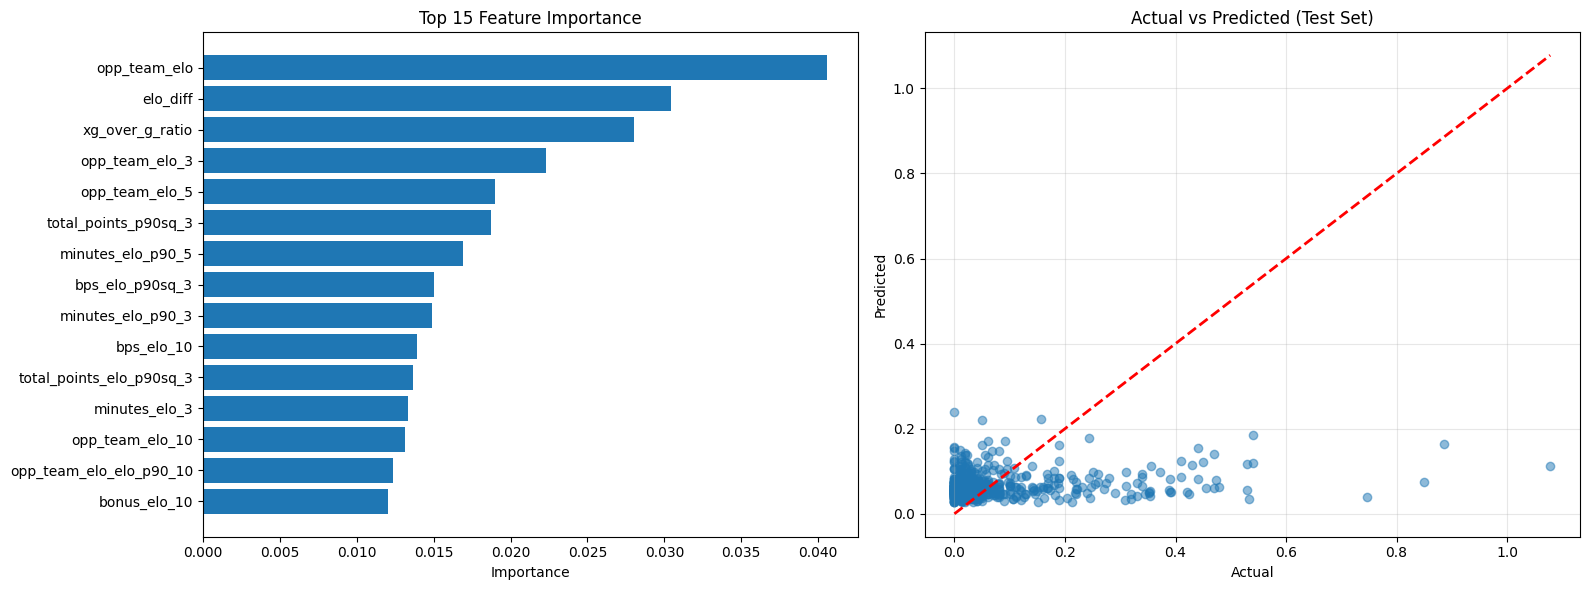

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12735/19361

Training Set Performance:
R² Score: 0.4035
RMSE: 0.1257
MAE: 0.0893

Test Set Performance:
R² Score: 0.0683
RMSE: 0.1583
MAE: 0.1081

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.100735
         bonus_p90sq_at    0.081400
    total_points_elo_10    0.023289
           opp_team_elo    0.022755
             bps_elo_10    0.022108
         opp_team_elo_5    0.019018
  goals_scored_p90sq_at    0.016653
                 bps_10    0.013253
        opp_team_elo_10    0.012480
           bps_p90sq_at    0.012149
  clean_sheets_p90sq_at    0.011715
goals_conceded_p90sq_at    0.011697
      team_elo_p90sq_at    0.011400
         opp_team_elo_3    0.011069
  total_points_p90sq_at    0.010522
               team_elo    0.009138
           bps_p90sq_10    0.008698
     minutes_elo_p90_10    0.008588
                  bps_3    0.008509
         minutes_elo_10    0.008392


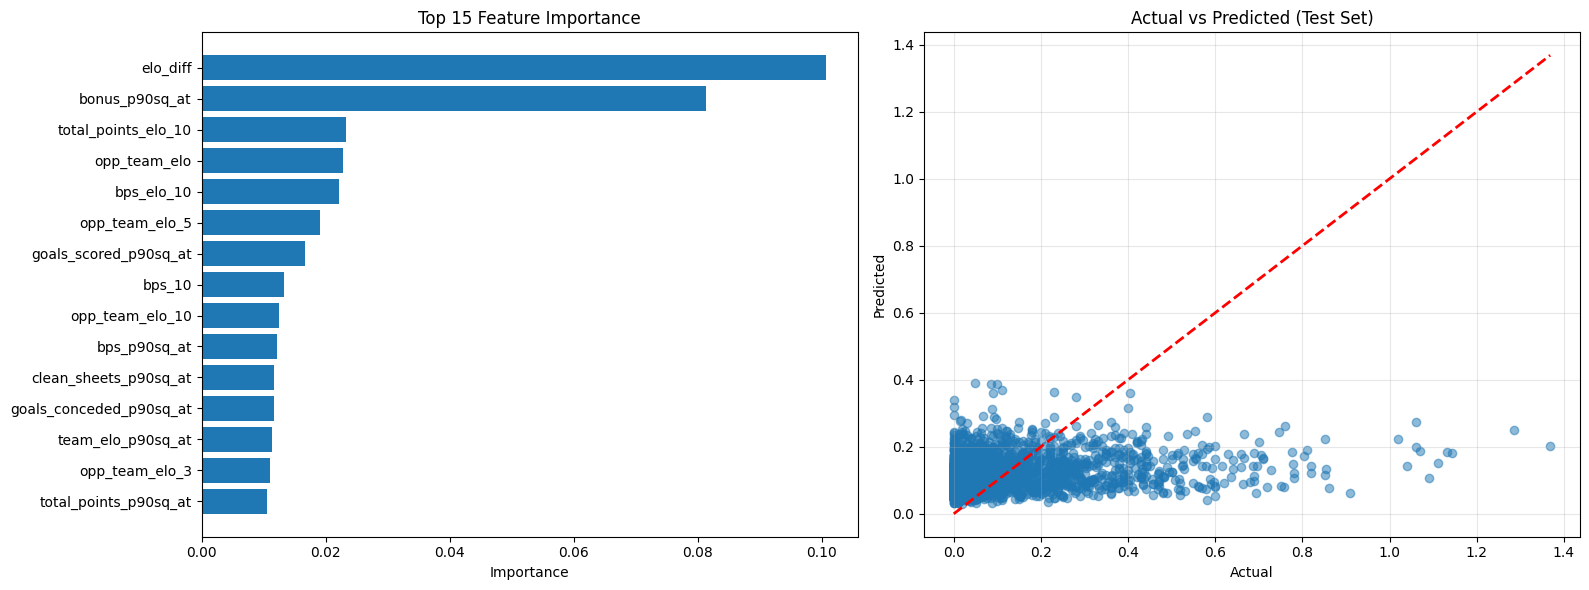

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10742/17077

Training Set Performance:
R² Score: 0.3773
RMSE: 0.0825
MAE: 0.0513

Test Set Performance:
R² Score: 0.0629
RMSE: 0.1011
MAE: 0.0571

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.092067
               elo_diff    0.039224
           opp_team_elo    0.030143
goals_conceded_p90sq_at    0.023733
        opp_team_elo_10    0.021378
                  bps_3    0.018148
            bps_p90sq_5    0.017311
   goals_conceded_elo_3    0.017271
  clean_sheets_p90sq_at    0.016465
  goals_scored_p90sq_at    0.016102
               team_elo    0.015550
           bps_p90sq_at    0.014464
          bps_elo_p90_5    0.012846
         opp_team_elo_3    0.012776
  total_points_p90sq_at    0.011957
  opp_team_elo_p90sq_at    0.011903
 total_points_elo_p90_5    0.011479
            bonus_elo_5    0.009795
      team_elo_p90sq_at    0.009751
             minutes_10    0.009570


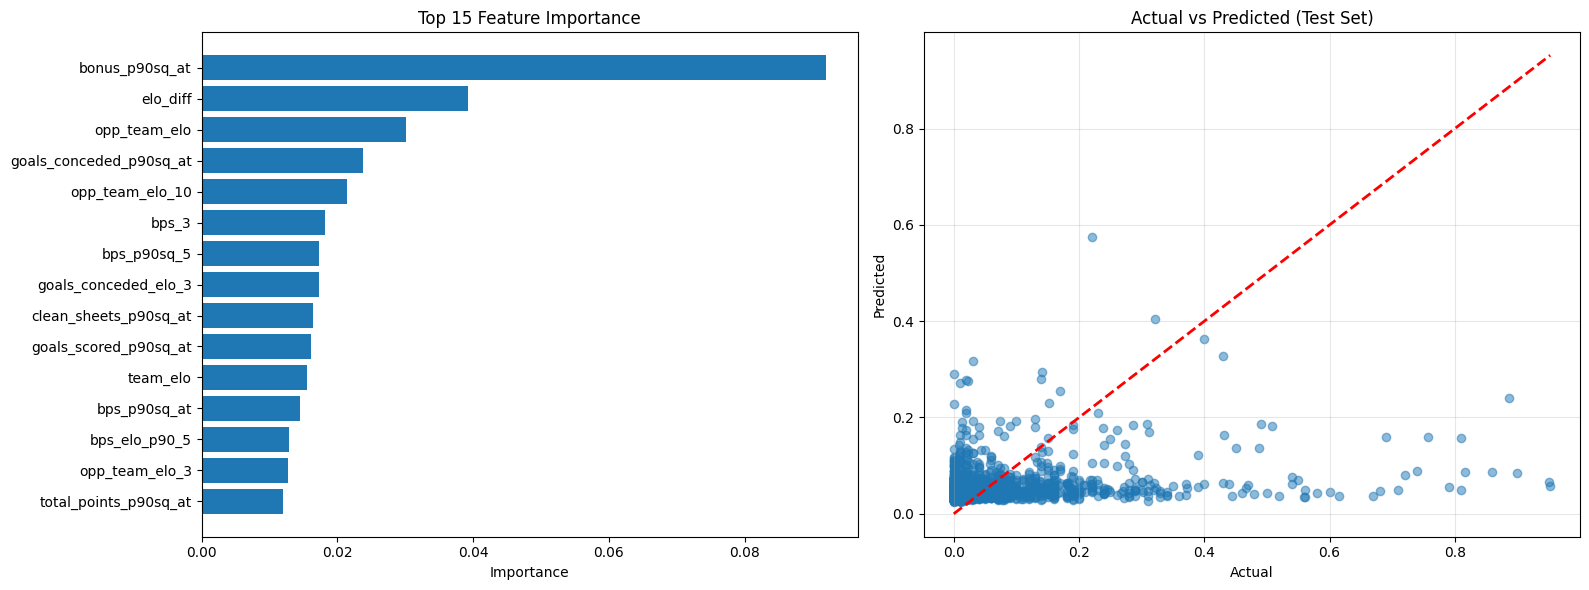

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2863/4667

Training Set Performance:
R² Score: 0.6446
RMSE: 0.5508
MAE: 0.4451

Test Set Performance:
R² Score: 0.1295
RMSE: 0.8654
MAE: 0.6747

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.164188
            xg_over_g_ratio    0.043991
               opp_team_elo    0.043642
      clean_sheets_p90sq_at    0.020582
    goals_conceded_p90sq_at    0.017160
            opp_team_elo_10    0.016681
             opp_team_elo_5    0.014817
        minutes_elo_p90sq_3    0.011546
       goals_conceded_elo_5    0.011108
             opp_team_elo_3    0.010941
             bonus_p90sq_at    0.010692
         minutes_elo_p90_10    0.010273
          team_elo_p90sq_at    0.009340
goals_conceded_elo_p90sq_10    0.009279
    goals_conceded_p90sq_10    0.008966
      total_points_p90sq_at    0.008955
          minutes_elo_p90_3    0.008632
              minutes_elo_3    0.0

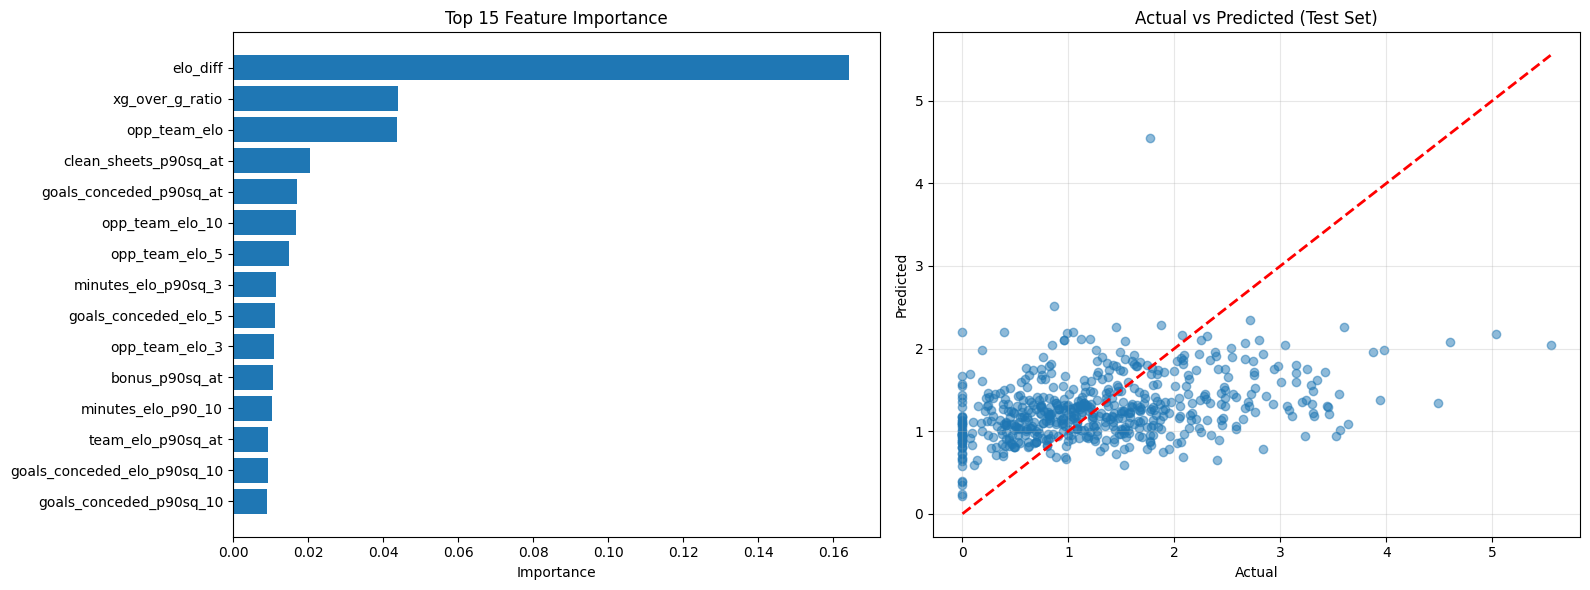

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12735/19361

Training Set Performance:
R² Score: 0.5250
RMSE: 0.6421
MAE: 0.5079

Test Set Performance:
R² Score: 0.3130
RMSE: 0.7674
MAE: 0.6049

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.244757
         opp_team_elo    0.078110
      opp_team_elo_10    0.037925
       opp_team_elo_5    0.032936
             team_elo    0.031866
           team_elo_5    0.026321
          team_elo_10    0.023087
       opp_team_elo_3    0.021687
       team_elo_elo_5    0.017662
           team_elo_3    0.017514
   opp_team_elo_elo_3    0.016678
   opp_team_elo_elo_5    0.014630
    minutes_elo_p90_3    0.013830
       team_elo_elo_3    0.013823
  minutes_elo_p90sq_3    0.013772
clean_sheets_p90sq_at    0.012340
  opp_team_elo_elo_10    0.011354
 minutes_elo_p90sq_10    0.009610
      team_elo_elo_10    0.009143
opp_team_elo_p90sq_at    0.008617


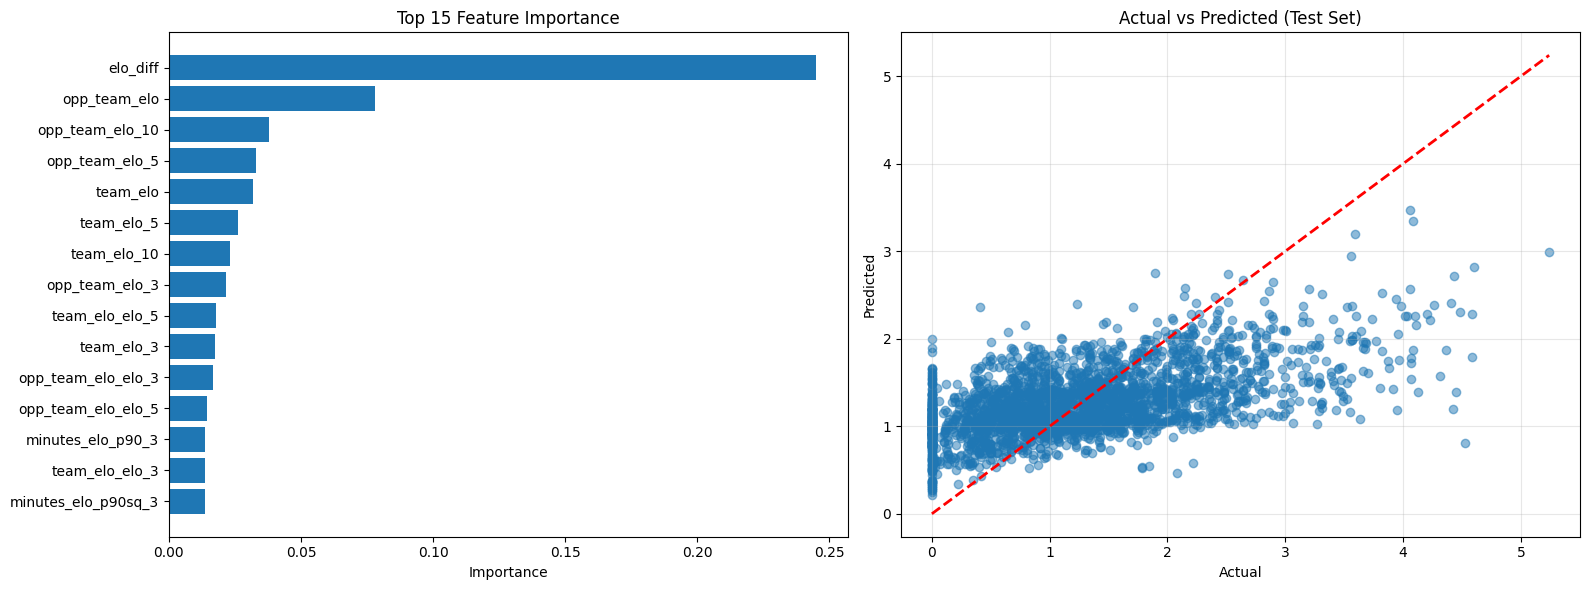

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10742/17077

Training Set Performance:
R² Score: 0.5623
RMSE: 0.6193
MAE: 0.4919

Test Set Performance:
R² Score: 0.2981
RMSE: 0.7593
MAE: 0.5915

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.201883
           opp_team_elo    0.091762
        opp_team_elo_10    0.036490
         opp_team_elo_5    0.030813
    opp_team_elo_elo_10    0.024906
               team_elo    0.020955
            team_elo_10    0.019162
         opp_team_elo_3    0.019049
  clean_sheets_p90sq_at    0.018506
     opp_team_elo_elo_3    0.017671
goals_conceded_p90sq_at    0.017293
         team_elo_elo_3    0.016368
             team_elo_5    0.016333
             team_elo_3    0.016073
    minutes_elo_p90sq_3    0.013742
         team_elo_elo_5    0.013043
     opp_team_elo_elo_5    0.012209
      minutes_elo_p90_3    0.011746
  opp_team_elo_p90sq_at    0.011222
        team_elo_elo_10    0.010

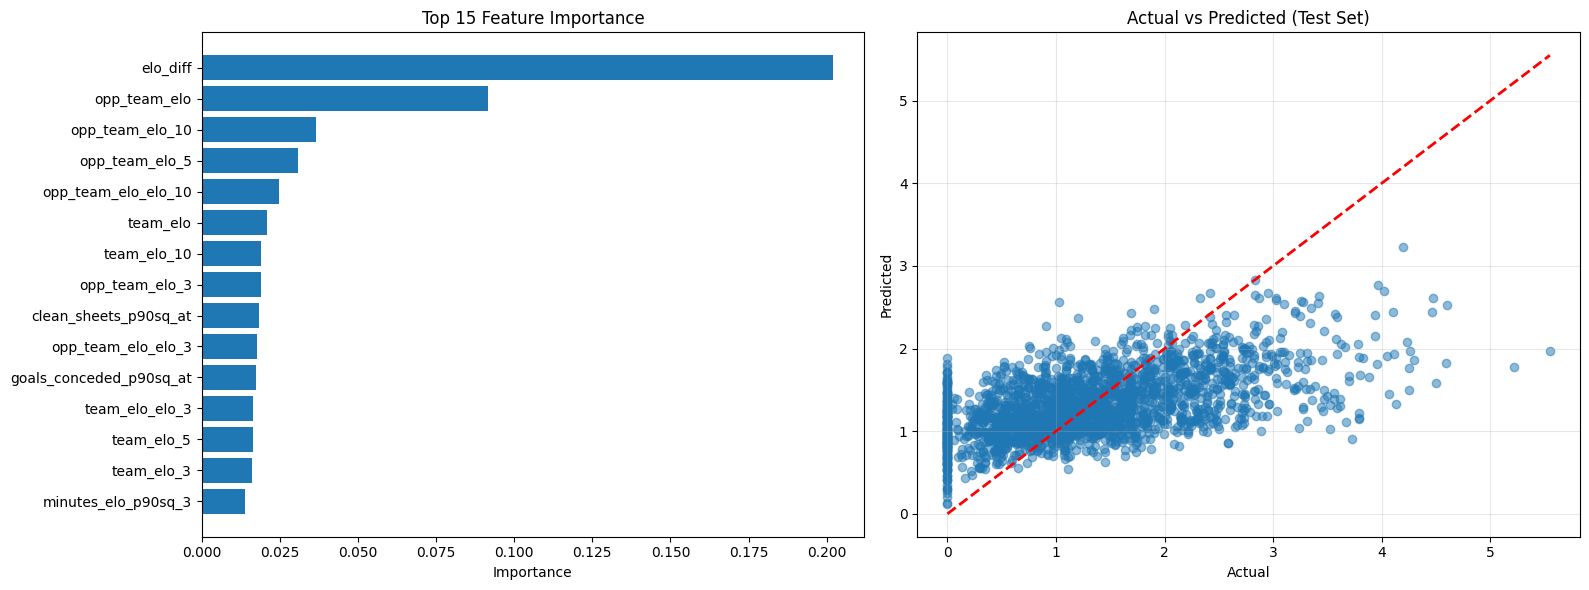

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2633/4174

Training Set Performance:
R² Score: 0.6953
RMSE: 0.5097
MAE: 0.4109

Test Set Performance:
R² Score: 0.1768
RMSE: 0.7998
MAE: 0.6402

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.171914
           opp_team_elo    0.041086
  opp_team_elo_p90sq_10    0.029953
         saves_p90sq_at    0.026451
  opp_team_elo_p90sq_at    0.023107
goals_conceded_p90sq_at    0.022829
        opp_team_elo_10    0.020313
      team_elo_p90sq_at    0.019029
      saves_elo_p90sq_3    0.014662
           bps_p90sq_at    0.014041
         opp_team_elo_5    0.013251
         saves_p90sq_10    0.012750
      saves_elo_p90sq_5    0.012728
         bonus_p90sq_at    0.012269
     saves_elo_p90sq_10    0.012122
   opp_team_elo_p90sq_5    0.011723
  clean_sheets_p90sq_at    0.011638
  total_points_p90sq_at    0.011189
           bps_p90sq_10    0.010380
   opp_team_elo_p90sq_3    0.010318

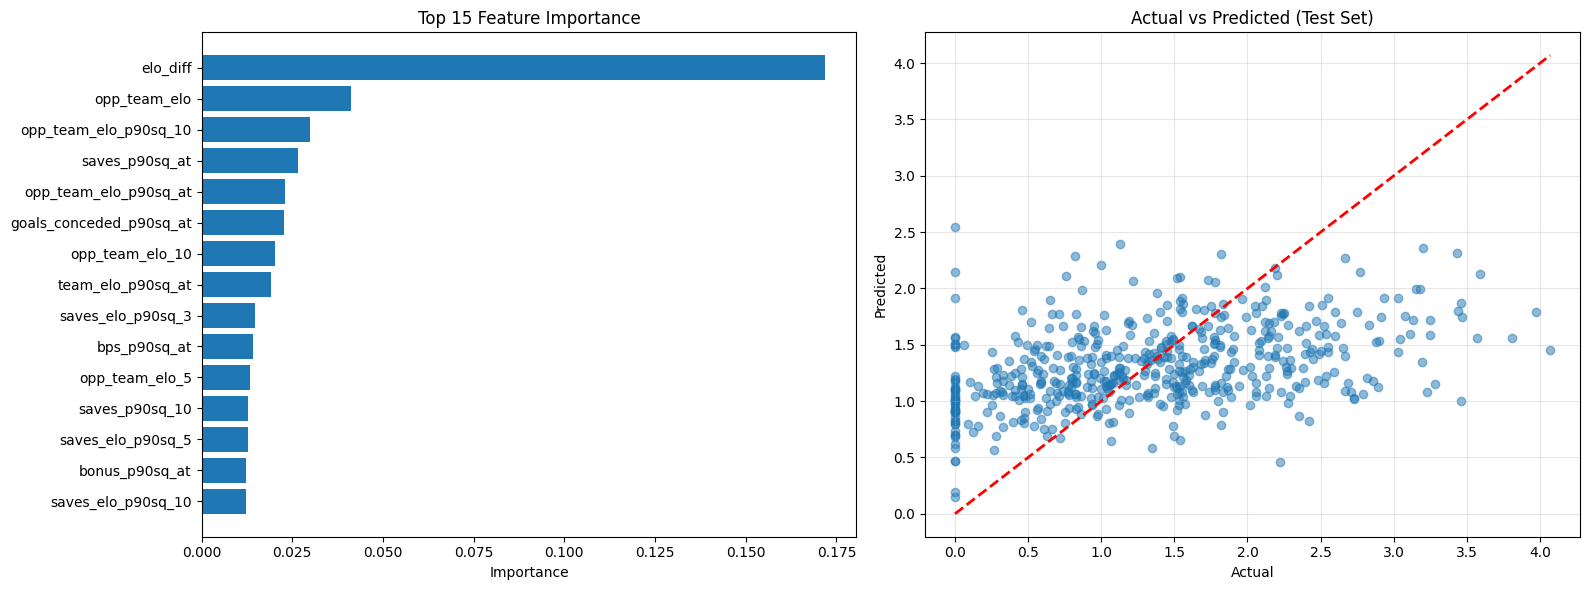

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4175/4667

Training Set Performance:
R² Score: 0.5074
RMSE: 13.2047
MAE: 10.7065

Test Set Performance:
R² Score: 0.0047
RMSE: 17.1866
MAE: 13.8184

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.070914
           opp_team_elo    0.026157
         bonus_p90sq_at    0.020029
   minutes_elo_p90sq_10    0.020027
goals_conceded_p90sq_at    0.017237
        opp_team_elo_10    0.017090
         opp_team_elo_3    0.014864
         opp_team_elo_5    0.014117
  total_points_p90sq_at    0.012805
  goals_scored_p90sq_at    0.011768
  clean_sheets_p90sq_at    0.010710
      minutes_elo_p90_5    0.010689
             bps_elo_10    0.010137
    clean_sheets_elo_10    0.009757
  opp_team_elo_p90sq_at    0.009627
              bps_elo_3    0.009615
      minutes_elo_p90_3    0.009598
    minutes_elo_p90sq_5    0.009267
           bps_p90sq_at    0.009068
     opp_team_elo_elo_5    0.008830


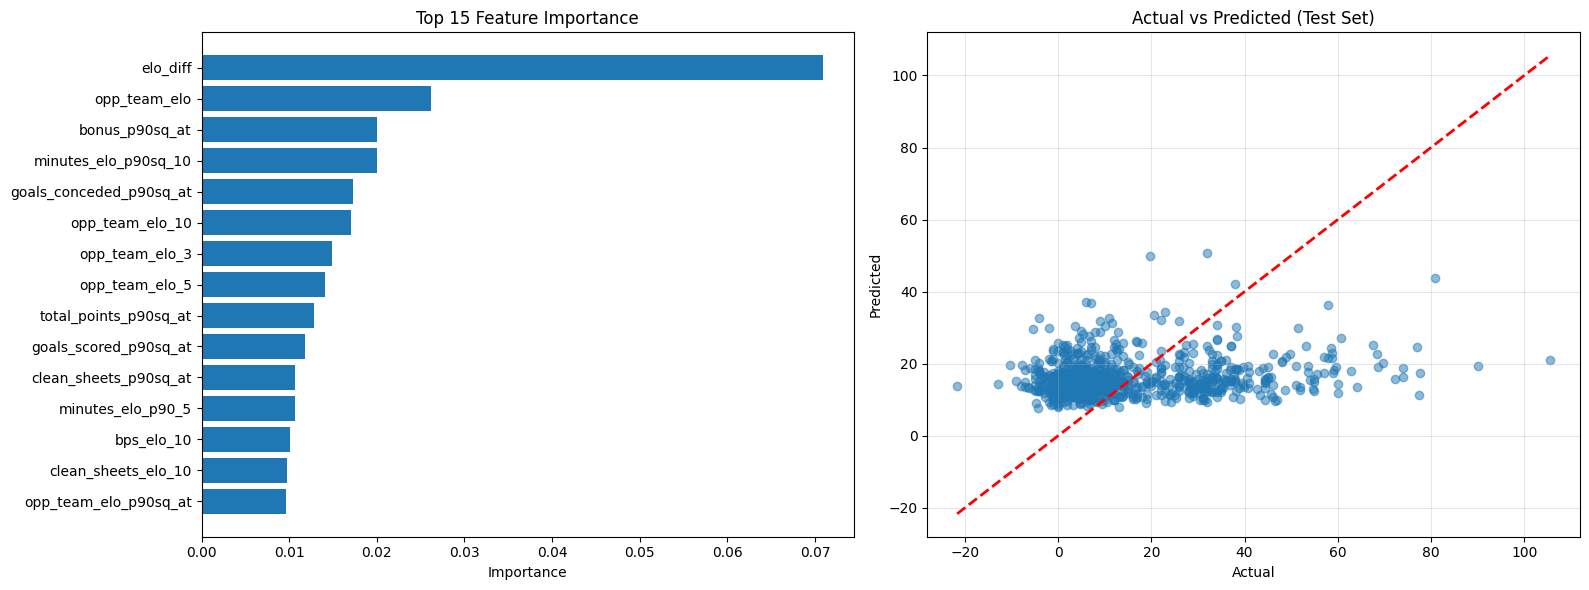

target=bps_per90, MID_bps_predictor
Cleaned df size: 18749/19361

Training Set Performance:
R² Score: 0.3147
RMSE: 9.4907
MAE: 7.2164

Test Set Performance:
R² Score: 0.0483
RMSE: 11.1222
MAE: 8.0014

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.137955
                 bps_10    0.035813
             bps_elo_10    0.023310
         bonus_p90sq_at    0.022733
           opp_team_elo    0.021655
        opp_team_elo_10    0.017218
                  bps_5    0.016049
         opp_team_elo_3    0.015261
  goals_scored_p90sq_at    0.011286
    total_points_elo_10    0.011238
         opp_team_elo_5    0.010663
  clean_sheets_p90sq_at    0.010552
goals_conceded_p90sq_at    0.009984
              bps_elo_5    0.009520
           bps_p90sq_at    0.008964
    clean_sheets_elo_10    0.008216
  total_points_p90sq_at    0.008112
            bps_p90sq_5    0.008105
           bps_p90sq_10    0.008077
goals_conceded_p90sq_10    0.007872


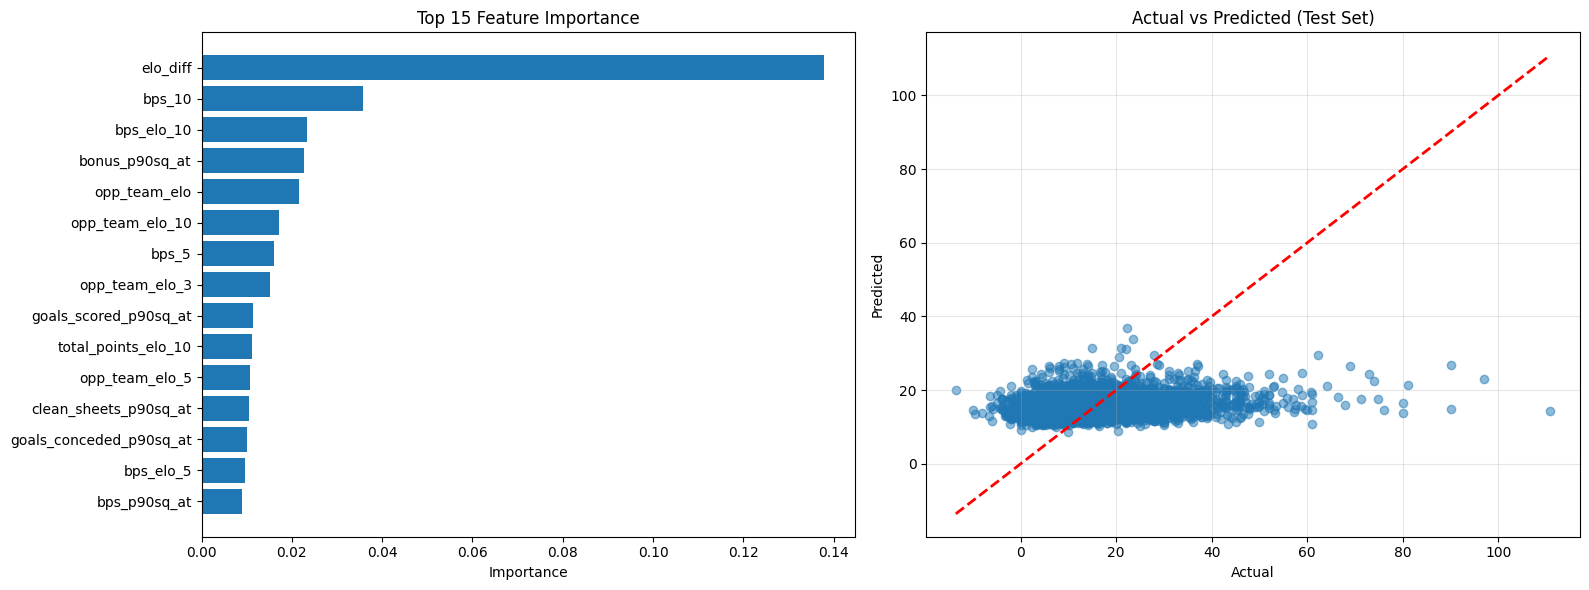

target=bps_per90, DEF_bps_predictor
Cleaned df size: 16069/17077

Training Set Performance:
R² Score: 0.4186
RMSE: 7.5745
MAE: 6.0629

Test Set Performance:
R² Score: 0.1372
RMSE: 9.1214
MAE: 7.1873

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.230762
           opp_team_elo    0.032206
        opp_team_elo_10    0.026250
         opp_team_elo_5    0.020885
         opp_team_elo_3    0.019387
         bonus_p90sq_at    0.015222
                 bps_10    0.013023
             bps_p90_10    0.012312
  clean_sheets_p90sq_at    0.011725
goals_conceded_p90sq_at    0.011567
            team_elo_10    0.011290
            bps_p90sq_5    0.010763
           bps_p90sq_at    0.010664
        bps_elo_p90sq_5    0.009377
               team_elo    0.008987
            bps_p90sq_3    0.008984
             bps_elo_10    0.008503
       bps_elo_p90sq_10    0.008366
              bps_elo_3    0.008217
  goals_scored_p90sq_at    0.008214


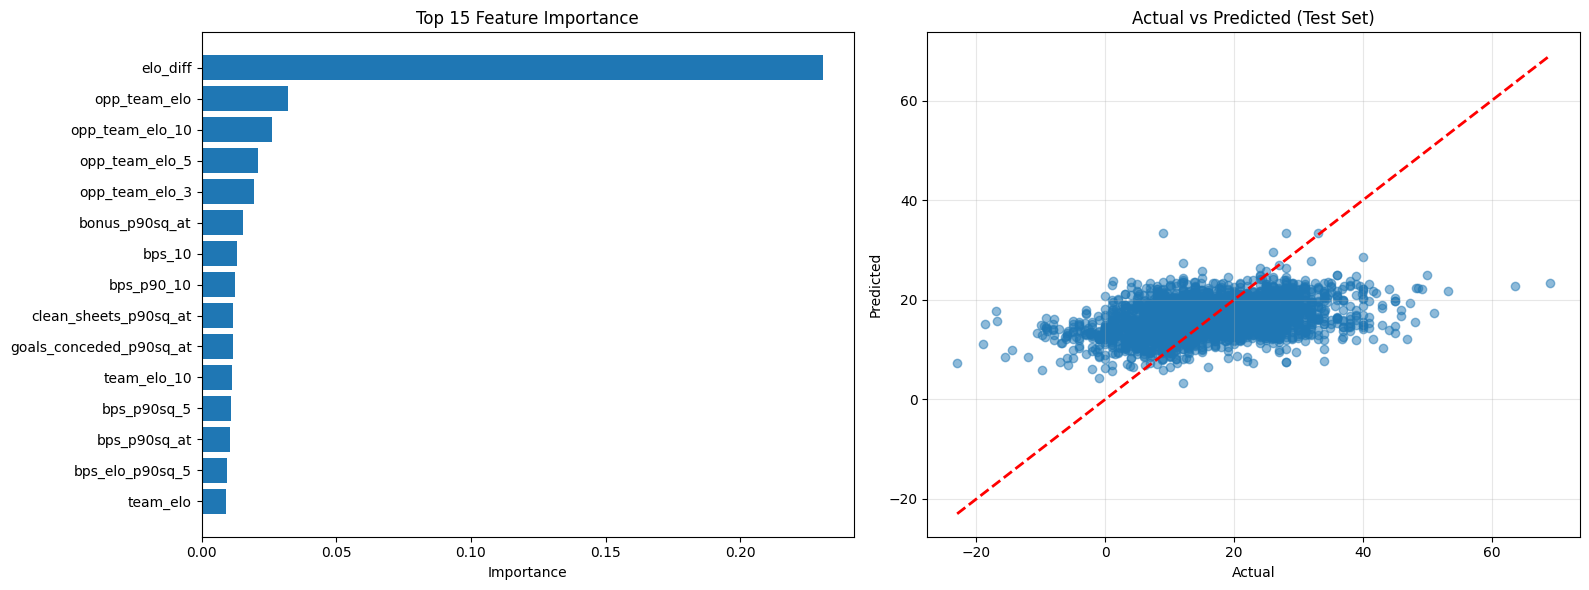

target=bps_per90, GK_bps_predictor
Cleaned df size: 3931/4174

Training Set Performance:
R² Score: 0.5289
RMSE: 6.0663
MAE: 4.9241

Test Set Performance:
R² Score: 0.0223
RMSE: 9.1333
MAE: 7.2450

Top 20 Feature Importances:
                feature  importance
           opp_team_elo    0.035613
        opp_team_elo_10    0.032515
           bps_p90sq_10    0.031916
             bps_p90_10    0.026863
  opp_team_elo_p90sq_at    0.023023
               elo_diff    0.018802
           bps_p90sq_at    0.017756
         opp_team_elo_5    0.017713
         saves_p90sq_10    0.017147
            bps_p90sq_3    0.015927
  opp_team_elo_p90sq_10    0.015858
       bps_elo_p90sq_10    0.015627
      saves_elo_p90sq_3    0.015594
            bps_p90sq_5    0.015446
goals_conceded_p90sq_at    0.015304
   opp_team_elo_p90sq_5    0.015018
          saves_p90sq_5    0.014973
                 bps_10    0.014913
     saves_elo_p90sq_10    0.013974
   opp_team_elo_p90sq_3    0.013827


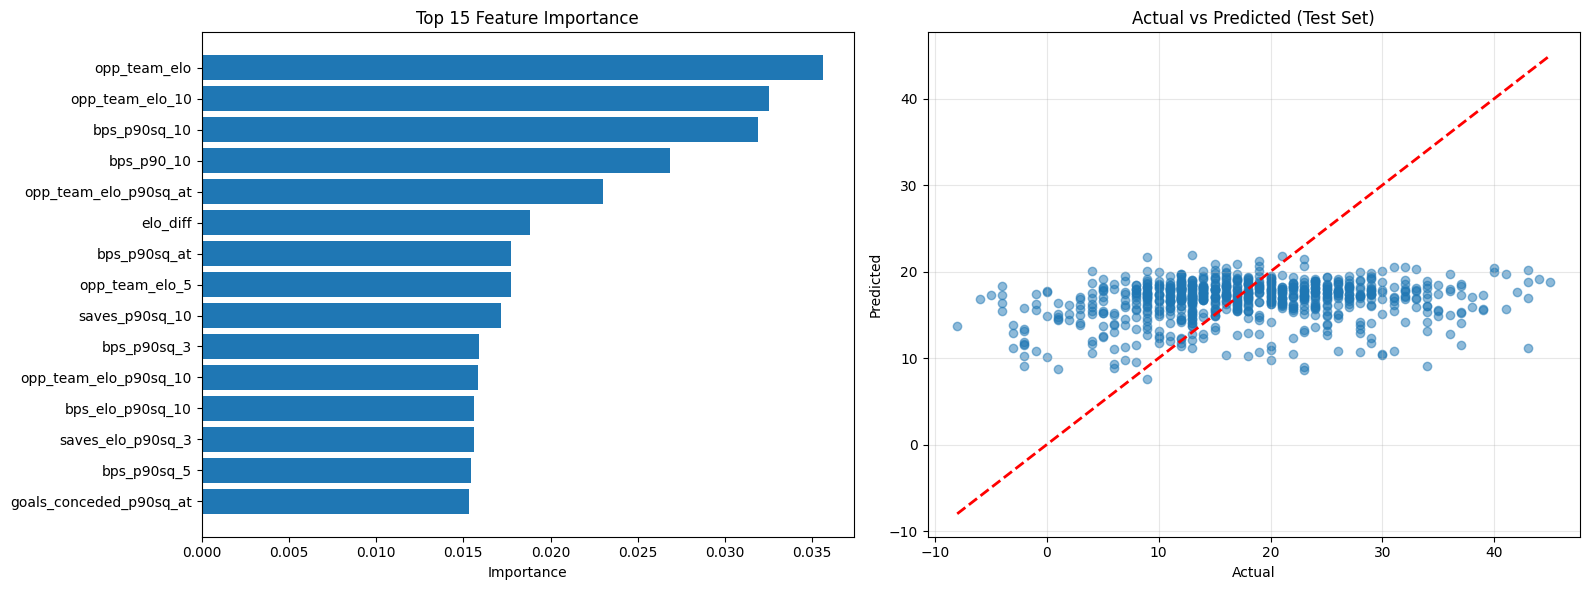

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3931/4195

Training Set Performance:
R² Score: 0.5726
RMSE: 1.2806
MAE: 1.0312

Test Set Performance:
R² Score: 0.0398
RMSE: 1.8988
MAE: 1.5086

Top 20 Feature Importances:
                 feature  importance
                elo_diff    0.143978
         opp_team_elo_10    0.019897
            opp_team_elo    0.019566
          opp_team_elo_5    0.018287
          saves_p90sq_at    0.017366
         bps_elo_p90sq_5    0.015585
   opp_team_elo_p90sq_at    0.015519
          saves_p90sq_10    0.013593
 goals_conceded_p90sq_at    0.013279
      saves_elo_p90sq_10    0.013249
total_points_elo_p90sq_5    0.012117
   total_points_p90sq_at    0.011886
       team_elo_p90sq_at    0.011700
          opp_team_elo_3    0.011595
            bps_p90sq_at    0.011527
          bonus_p90sq_at    0.011167
   opp_team_elo_p90sq_10    0.011077
total_points_elo_p90sq_3    0.010906
            bps_p90sq_10    0.010564
       saves_elo_p90sq_5    0.0

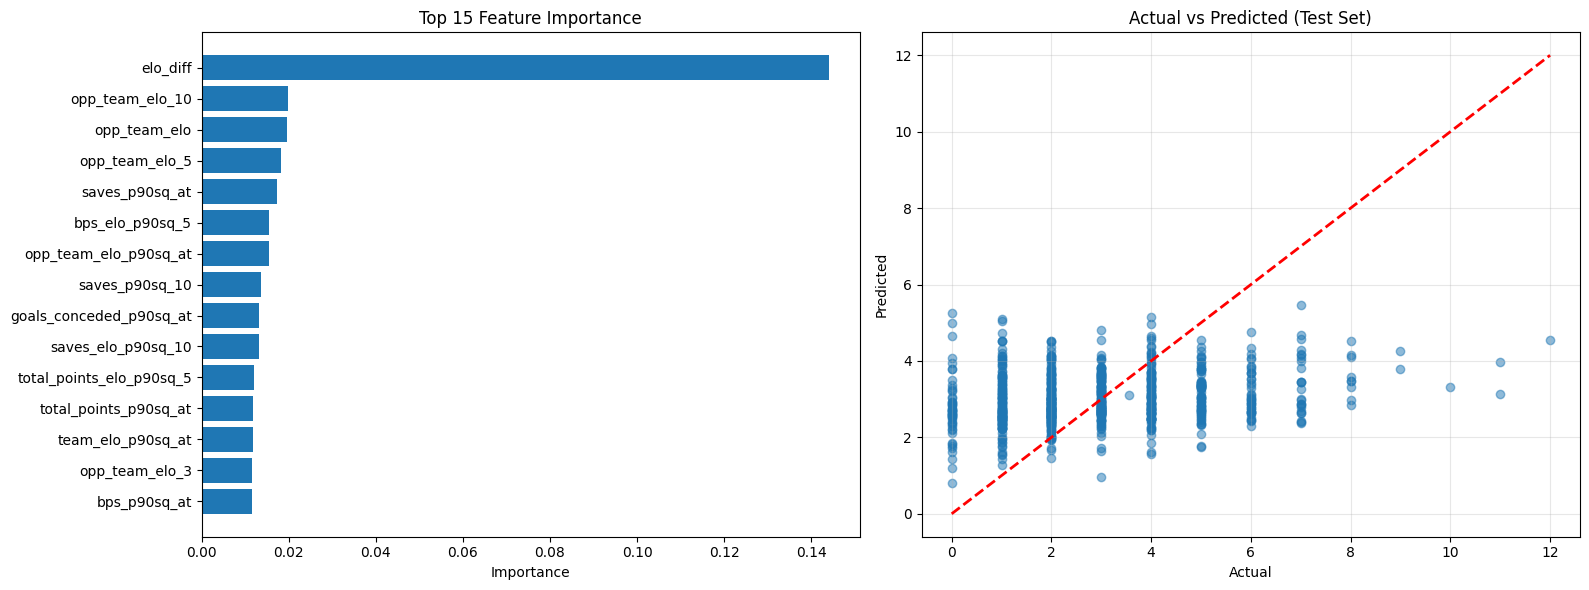

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 671/5159

Training Set Performance:
R² Score: 0.7749
RMSE: 1.3849
MAE: 1.1076

Test Set Performance:
R² Score: 0.0279
RMSE: 2.5953
MAE: 2.0696

Top 20 Feature Importances:
                   feature  importance
                minutes_10    0.036866
     goals_conceded_p90_10    0.031478
            opp_team_elo_5    0.025480
     clean_sheets_p90sq_at    0.023754
           xg_over_g_ratio    0.023192
      opp_team_elo_p90sq_3    0.017845
        minutes_elo_p90_10    0.017842
     opp_team_elo_p90sq_at    0.016963
            opp_team_elo_3    0.016057
               bps_p90sq_5    0.015808
      total_points_p90sq_3    0.015558
            bonus_p90sq_at    0.015476
     goals_scored_p90sq_at    0.014406
     goals_conceded_elo_10    0.014167
           opp_team_elo_10    0.013948
                  elo_diff    0.013602
   goals_conceded_p90sq_at    0.013288
              bps_p90sq_at    0.012554
            

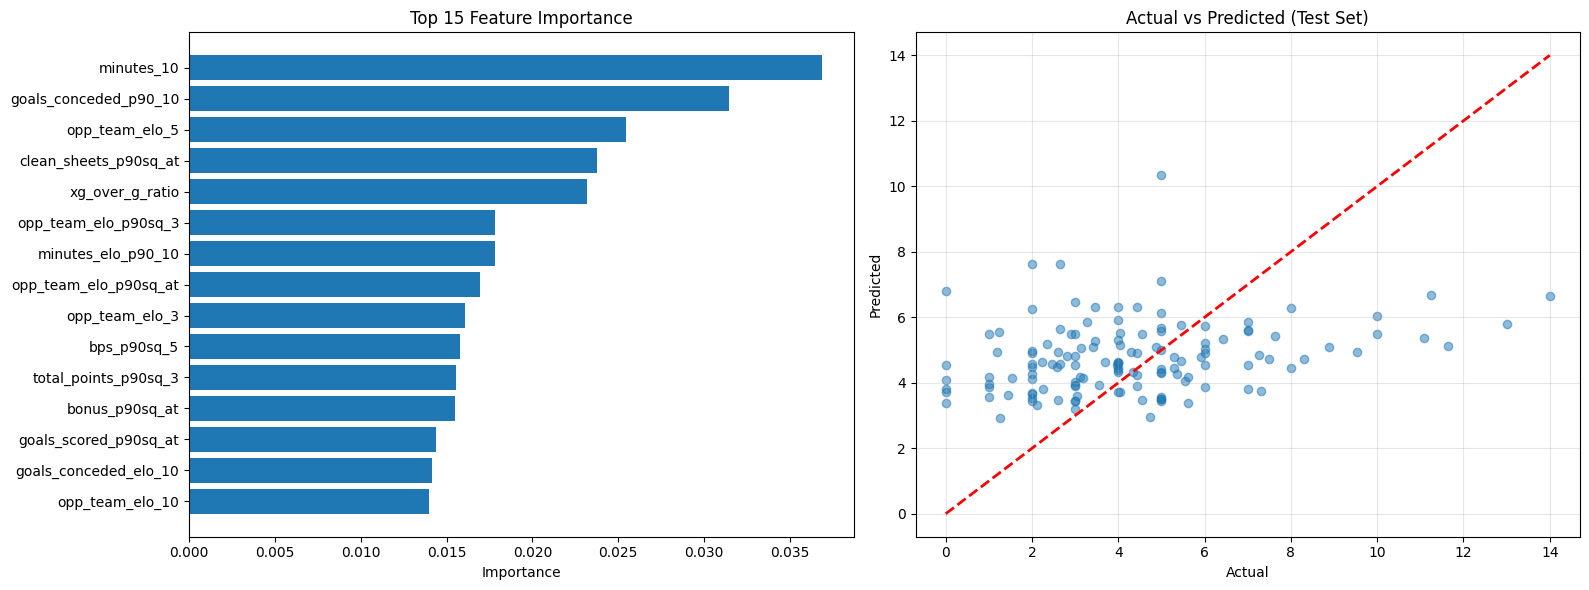

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 3028/21292

Training Set Performance:
R² Score: 0.6598
RMSE: 2.4484
MAE: 1.9743

Test Set Performance:
R² Score: 0.1907
RMSE: 3.7968
MAE: 3.0456

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.102605
         bonus_p90sq_at    0.035609
goals_conceded_p90sq_at    0.031405
  total_points_p90sq_at    0.029389
           bps_p90sq_at    0.020111
         opp_team_elo_3    0.015037
           opp_team_elo    0.013938
               team_elo    0.012967
       team_elo_p90sq_5    0.012953
      team_elo_p90sq_at    0.012754
  opp_team_elo_p90sq_at    0.011068
   opp_team_elo_p90sq_3    0.010904
        opp_team_elo_10    0.010562
   goals_conceded_elo_3    0.010554
    team_elo_elo_p90_10    0.010473
               elo_diff    0.010420
            bps_p90sq_5    0.010351
         opp_team_elo_5    0.010340
             team_elo_3    0.010119
  clean_sheets_p90sq_at    0.01

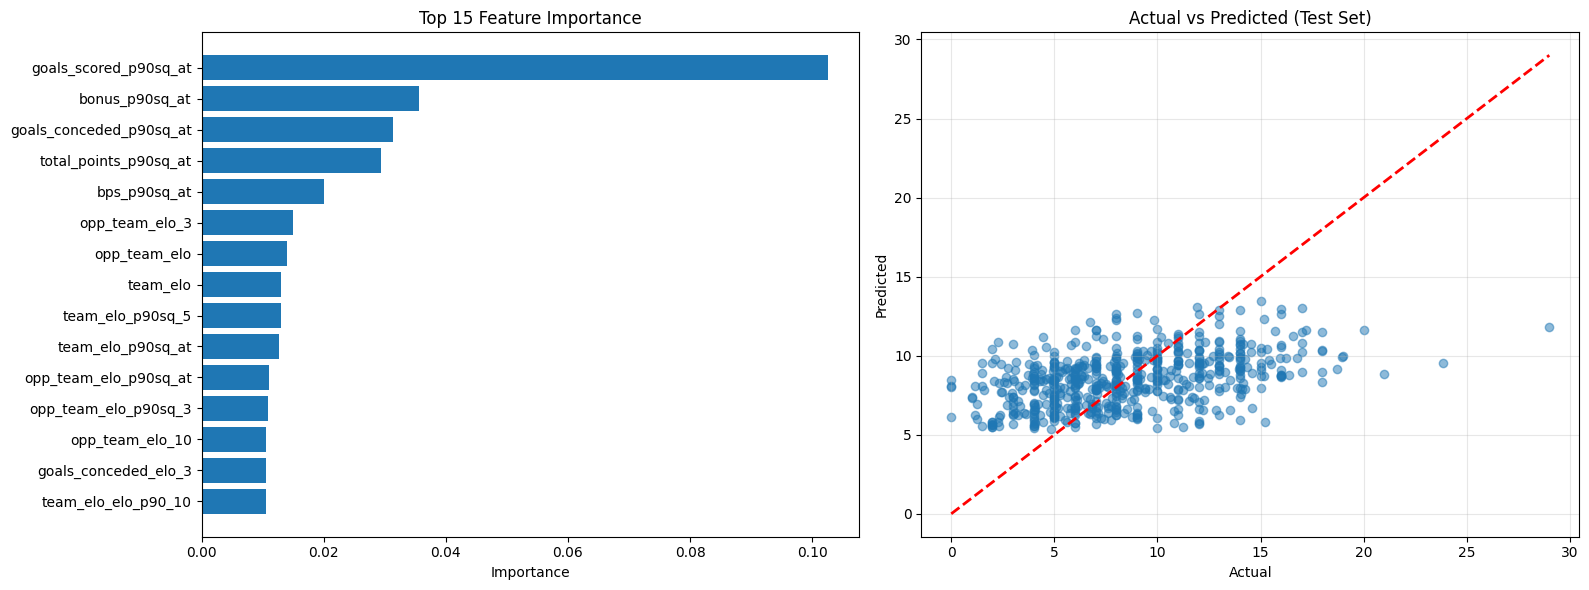

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2535/18048

Training Set Performance:
R² Score: 0.6415
RMSE: 2.3396
MAE: 1.8856

Test Set Performance:
R² Score: 0.0835
RMSE: 3.6294
MAE: 2.9066

Top 20 Feature Importances:
                                   feature  importance
                                cbi_p90_at    0.064526
                         recoveries_p90_at    0.030391
xgoal_involvements_x_defensive_cont_p90_at    0.026920
                                  elo_diff    0.021676
                              opp_team_elo    0.019512
                     opp_team_elo_p90sq_at    0.019243
                   goals_conceded_p90sq_at    0.017827
                     total_points_p90sq_at    0.017777
                      opp_team_elo_p90sq_5    0.016199
                            tackles_p90_at    0.014936
                     goals_scored_p90sq_at    0.014906
                            opp_team_elo_3    0.014469
                            bonus_p9

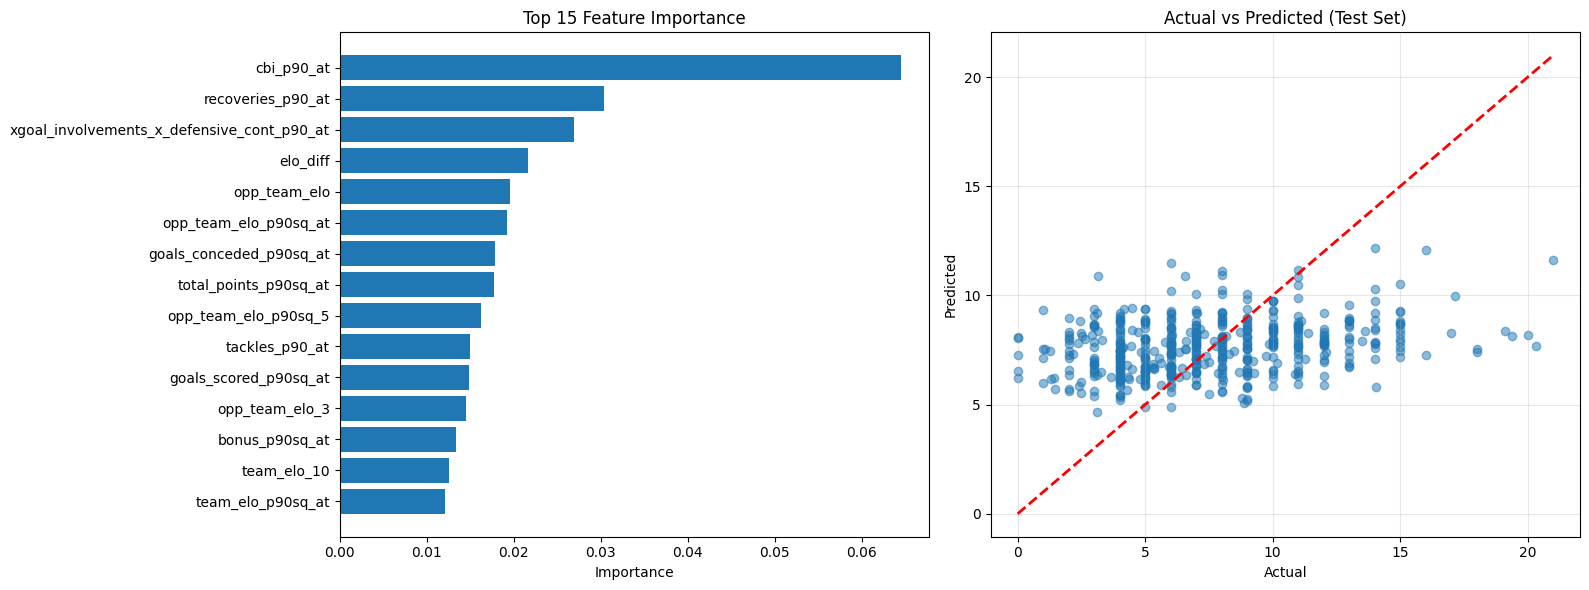

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

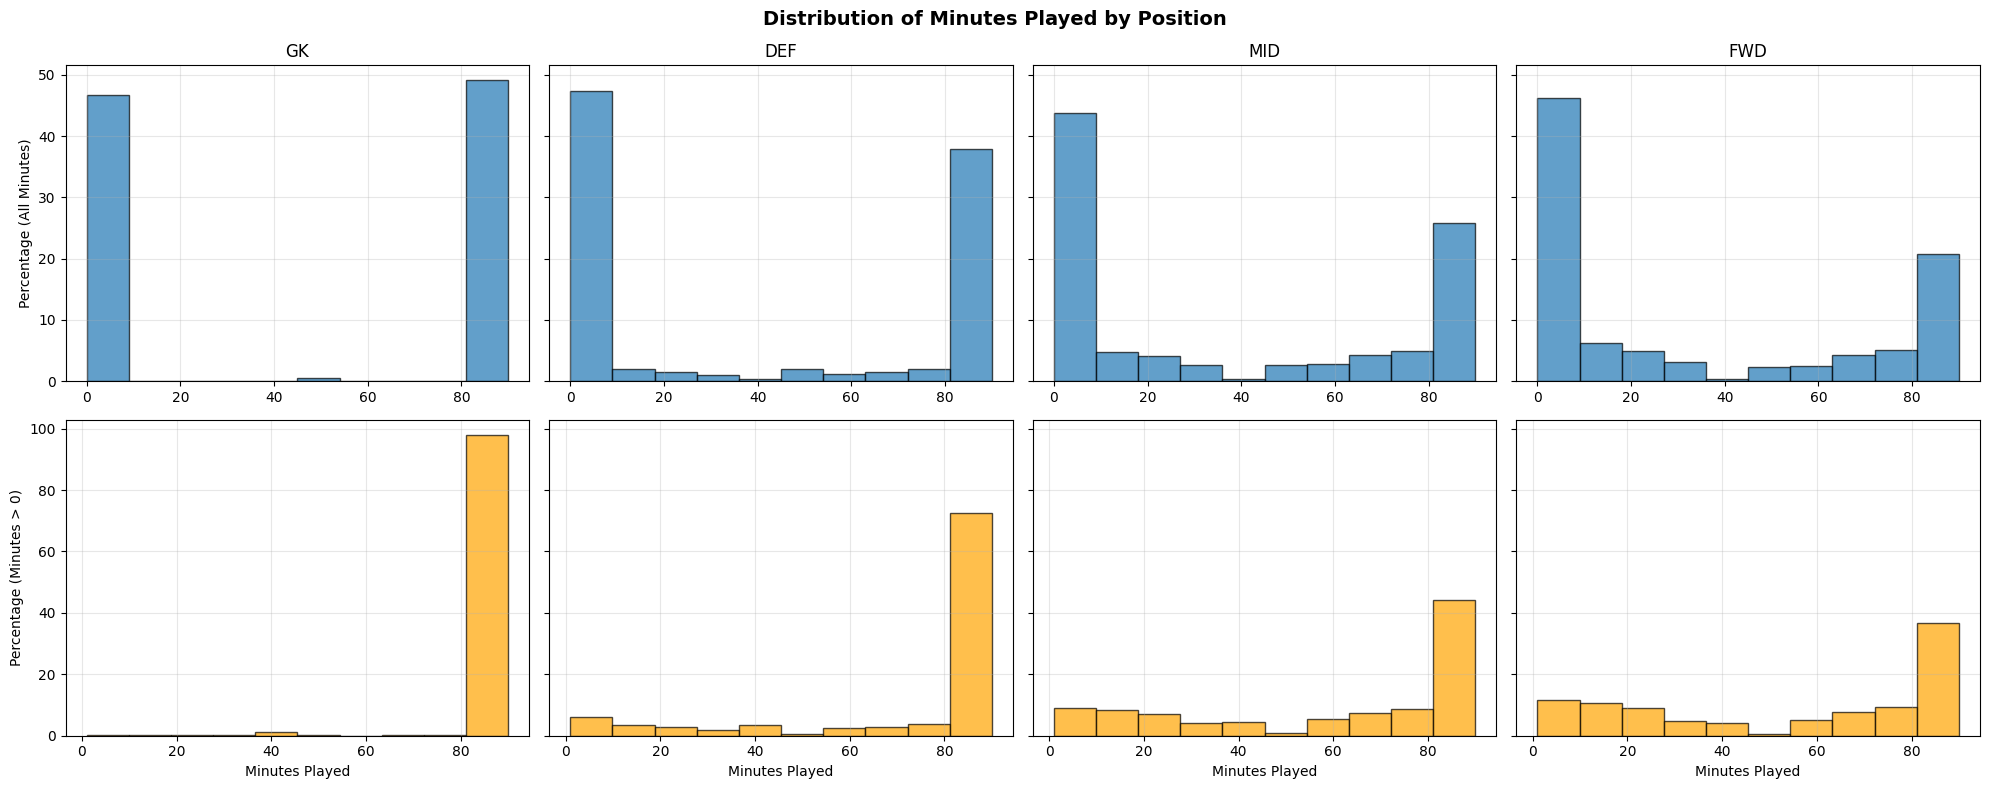

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.358


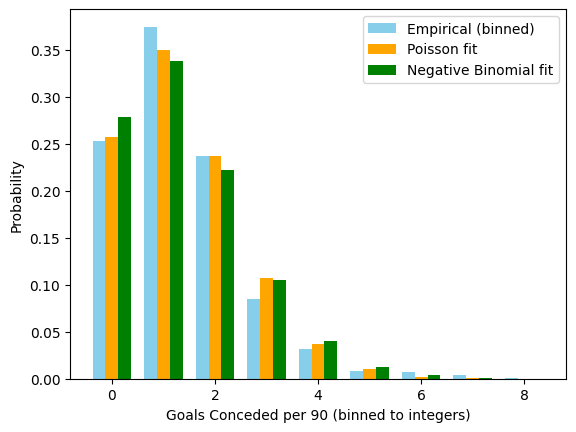

Mean: 1.349, Variance: 1.502
Overdispersion ratio (Var/Mean): 1.114
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.257


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.219


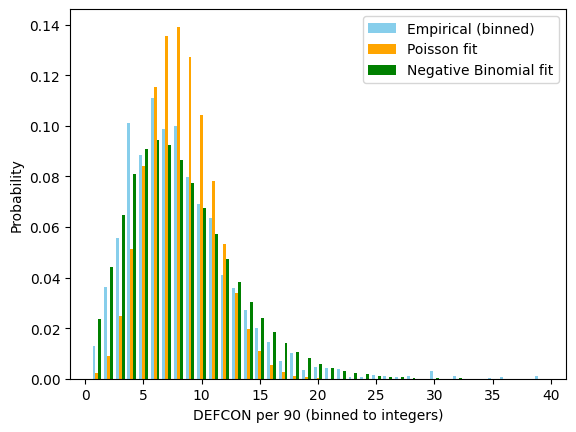

Mean: 8.211, Variance: 21.357
Overdispersion ratio (Var/Mean): 2.601
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.199


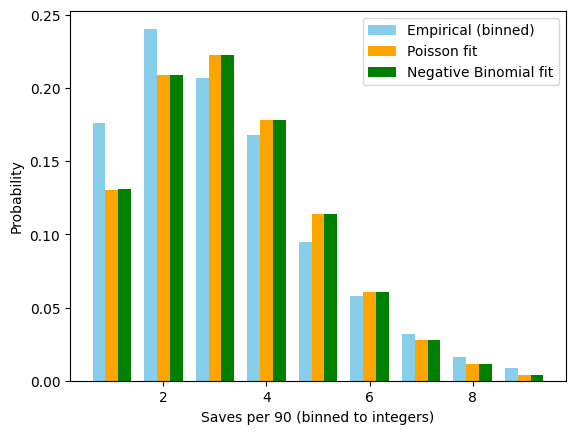

Mean: 3.199, Variance: 3.205
Overdispersion ratio (Var/Mean): 1.002
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    3640.000000
mean       60.164794
std        20.296388
min        17.307283
25%        42.583805
50%        60.671940
75%        79.872566
max        89.951552
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    3395.000000
mean        0.173995
std         0.145777
min         0.027281
25%         0.057684
50%         0.129662
75%         0.242094
max         0.752433
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    3395.000000
mean        0.105210
std         0.070869
min         0.025645
25%         0.051915
50%         0.078323
75%         0.143067
max         0.418493
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    3640.000000
mean        1.413439
std         0.327520
min         0.417707
25%         1.167872
50%         1.396532
75%         1.615868
max         2.701115
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    3640.000000
mean       15.886700
std         3.434396
min         4.651187
25%        13.614527
50%        15.456681
75%        17.837834
max        39.015371
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.524e+04
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                        0.00
Time:                        10:20:35   Log-Likelihood:                         -40891.
No. Observations:               43407   AIC:                                  8.178e+04
Df Residuals:                   43406   BIC:                                  8.179e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

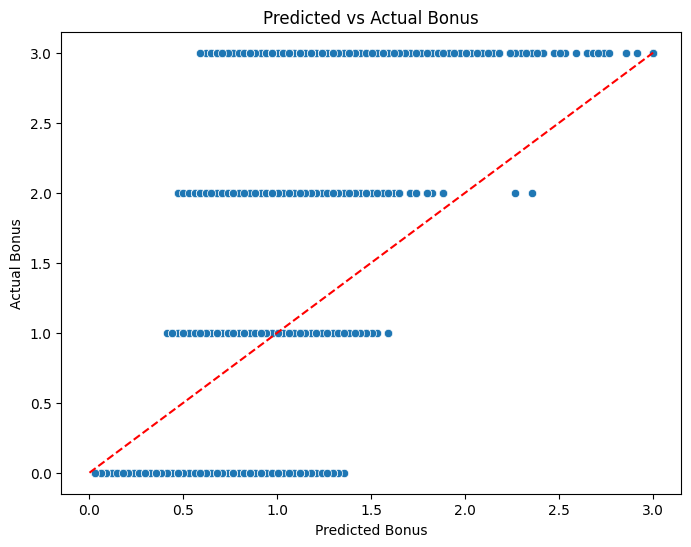

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458737  0.228284  1.105792  1.946898
FWD           0.332514  0.196592  1.045951  1.706910
GK            0.488119  0.243940  1.113811  2.006460
GKP                NaN       NaN       NaN       NaN
MID           0.397433  0.244936  1.048187  1.824012


C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    245.000000
mean       3.160026
std        0.586609
min        1.264348
25%        2.799322
50%        3.021517
75%        3.457119
max        4.981093
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    3395.000000
mean        7.922030
std         1.810804
min         3.374987
25%         6.765798
50%         8.027105
75%         9.258958
max        14.724393
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129543,Bendito Mantato,769.0,45.0,Man Utd,MID,20252026.0,32.0,Leeds,984.361246,39.813898,0.104534,0.292077,1.724149
129546,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,32.0,Arsenal,1258.933285,37.066313,0.123466,0.169693,1.780459
130028,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,945.878275,34.947488,0.095980,0.088236,1.070516
130036,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1047.736973,33.848510,0.090963,0.075210,1.501481
130038,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,34.0,Everton,1075.163339,33.848510,0.090729,0.076996,1.529045


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130101,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,32.0,Fulham,1048.665084,30.634810,0.741961,0.303540,1.466330
138961,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,32.0,Liverpool,1151.485697,32.428320,0.741095,0.258985,2.144258
134397,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,32.0,Newcastle,1078.258565,41.244736,0.727977,0.231656,1.456455
141537,Marc Guiu Paz,252.0,41.0,Chelsea,FWD,20252026.0,32.0,Man City,1226.620831,42.723894,0.727495,0.252480,2.019005
135686,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,32.0,Everton,1075.163339,38.393849,0.689635,0.204511,2.012464
132542,Charalampos Kostoulas,181.0,48.0,Brighton,FWD,20252026.0,32.0,Burnley,885.332865,27.224911,0.646984,0.402223,1.292263
135722,Gabriel Fernando de Jesus,31.0,64.0,Arsenal,FWD,20252026.0,32.0,Bournemouth,1068.145599,45.543122,0.645049,0.329873,1.324649
146286,Romain Esse,269.0,47.0,Crystal Palace,MID,20252026.0,32.0,Newcastle,1078.258565,35.379192,0.607053,0.203582,2.014427
144458,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,32.0,Newcastle,1078.258565,26.429146,0.598889,0.283566,1.638218
138385,Jean-Philippe Mateta,283.0,75.0,Crystal Palace,FWD,20252026.0,32.0,Newcastle,1078.258565,45.784428,0.591877,0.072554,1.350925


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_10388\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3640 entries, 0 to 3639
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          3640 non-null   object 
 1   team_name               3640 non-null   object 
 2   team_elo                3640 non-null   float64
 3   element                 3640 non-null   float64
 4   position                3640 non-null   object 
 5   opp_team_name           3640 non-null   object 
 6   opp_team_elo            3640 non-null   float64
 7   season                  3640 non-null   float64
 8   value                   3640 non-null   float64
 9   event                   3640 non-null   float64
 10  mins_pred               3640 non-null   float64
 11  xgp90_pred              3395 non-null   float64
 12  xap90_pred              3395 non-null   float64
 13  xgcp90_pred             3640 non-null   float64
 14  xpoints_mins            3640 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 32 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
144163,Nico O'Reilly,411.0,32.0,51.0,Man City,DEF,Chelsea,1112.865267,77.256598,1.848856,1.242720,0.156968,1.461785,0.0,-0.286706,0.541147,0.578003,5.542774
133126,Conor Bradley,375.0,32.0,49.0,Liverpool,DEF,Fulham,1048.665084,68.731994,1.705411,1.348239,0.821066,0.819851,0.0,-0.552961,0.541147,0.570091,5.252844
131274,Arthur Masuaku,678.0,32.0,39.0,Sunderland,DEF,Spurs,958.476619,61.687777,1.542095,1.631310,0.230984,1.145618,0.0,-0.395681,0.541147,0.526874,5.222346
135908,Gabriel dos Santos Magalhães,5.0,32.0,72.0,Arsenal,DEF,Bournemouth,1068.145599,84.405916,1.919871,0.375658,0.359920,1.685590,0.0,-0.226483,0.541147,0.549119,5.204821
132243,Bruno Borges Fernandes,449.0,32.0,102.0,Man Utd,MID,Leeds,984.361246,78.840551,1.868076,0.999107,0.706699,0.339103,0.0,0.000000,0.507861,0.777178,5.198024
139884,Jurriën Timber,8.0,32.0,63.0,Arsenal,DEF,Bournemouth,1068.145599,78.213410,1.860727,0.530499,0.199269,1.604506,0.0,-0.246965,0.541147,0.543216,5.032399
145537,Piero Hincapié,725.0,32.0,51.0,Arsenal,DEF,Bournemouth,1068.145599,72.159572,1.771351,0.299469,0.152327,1.827098,0.0,-0.193943,0.541147,0.527302,4.924751
143745,Nayef Aguerd,607.0,32.0,44.0,West Ham,DEF,Wolves,945.878275,61.023232,1.525559,1.507350,0.106776,1.194463,0.0,-0.376591,0.541147,0.415532,4.914235
131073,Antoine Semenyo,82.0,32.0,83.0,Man City,MID,Chelsea,1112.865267,82.517882,1.904805,1.031561,0.490048,0.325815,0.0,0.000000,0.507861,0.565981,4.826071
139697,Joško Gvardiol,403.0,32.0,59.0,Man City,DEF,Chelsea,1112.865267,57.730451,1.443504,1.382603,0.223016,0.999786,0.0,-0.458871,0.541147,0.668069,4.799253


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW32 - GW36


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,386.282075,9.244185,6.390299,0.801823,8.117999,0.0,-1.265706,2.705735,2.882207,28.876542
161,Gabriel dos Santos Magalhães,422.029578,9.599354,1.928258,1.800938,8.569891,0.0,-1.108724,2.705735,2.698670,26.194122
267,Jurriën Timber,391.067049,9.303635,2.693653,1.011597,8.339168,0.0,-1.163978,2.705735,2.647393,25.537202
87,Conor Bradley,343.421193,8.522085,6.788762,3.994125,3.859351,0.0,-2.913471,2.705735,2.522844,25.479431
263,Joško Gvardiol,288.146316,7.205609,6.906607,1.146464,5.631377,0.0,-2.055146,2.705735,3.310847,24.851493
64,Bruno Borges Fernandes,394.202754,9.340381,4.985941,2.997213,1.515125,0.0,0.000000,2.539306,3.421262,24.799228
32,Antoine Semenyo,412.727223,9.525207,5.611124,2.381016,1.772948,0.0,0.000000,2.539306,2.834173,24.663774
413,Piero Hincapié,361.536103,8.868835,1.446486,0.761115,9.061704,0.0,-0.986122,2.705735,2.530585,24.388339
334,Matheus Nunes,419.889675,9.583274,1.185385,1.243924,7.918579,0.0,-1.341272,2.705735,2.974804,24.270430
504,William Saliba,409.533343,9.497041,1.451464,0.851710,8.184645,0.0,-1.210238,2.705735,2.651360,24.131717


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,540.795271,12.941898,8.881115,1.106489,11.040884,0.0,-1.839320,3.788029,4.066513,39.985607
161,Gabriel dos Santos Magalhães,590.841409,13.439095,2.709406,2.680254,12.553957,0.0,-1.444395,3.788029,3.781992,37.508338
267,Jurriën Timber,546.986683,13.018897,3.797308,1.492671,12.298247,0.0,-1.506942,3.788029,3.728112,36.616321
87,Conor Bradley,480.725996,11.929594,9.510568,5.564200,5.324692,0.0,-4.127782,3.788029,3.460117,35.449416
504,William Saliba,573.346681,13.295858,2.085865,1.247688,12.286136,0.0,-1.533469,3.788029,3.748607,34.918714
64,Bruno Borges Fernandes,551.883855,13.076533,6.979847,4.227630,2.122890,0.0,0.000000,3.555028,4.848766,34.810695
413,Piero Hincapié,504.122372,12.379551,2.065358,1.114718,13.151684,0.0,-1.296244,3.788029,3.568313,34.771409
263,Joško Gvardiol,403.403930,10.087605,9.655924,1.602809,7.673464,0.0,-2.953422,3.788029,4.699917,34.554326
32,Antoine Semenyo,577.762987,13.334816,7.722971,3.368673,2.446145,0.0,0.000000,3.555028,3.983077,34.410711
242,John Stones,401.473243,10.039691,9.487966,1.957318,6.762972,0.0,-3.389442,3.788029,4.947020,33.593554


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 3640 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
104229,Erling Haaland,32.0,20252026.0,NaN
107866,Erling Haaland,32.0,20252026.0,NaN


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
183689,Erling Haaland,13.0,20252026.0,2.0,90.0
183690,Erling Haaland,14.0,20252026.0,14.0,90.0
183691,Erling Haaland,15.0,20252026.0,2.0,68.0
183692,Erling Haaland,16.0,20252026.0,13.0,90.0
183693,Erling Haaland,17.0,20252026.0,16.0,90.0
183694,Erling Haaland,18.0,20252026.0,2.0,90.0
183695,Erling Haaland,19.0,20252026.0,2.0,90.0
183696,Erling Haaland,20.0,20252026.0,2.0,90.0
183697,Erling Haaland,21.0,20252026.0,6.0,90.0
183698,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
87905,Erling Haaland,2026-03-09 11:36:31.677192,38.0,4.273248,NaN
71670,Erling Haaland,2026-02-22 11:15:02.719357,38.0,4.363917,NaN
103027,Erling Haaland,2026-03-22 14:21:44.947964,38.0,4.513632,NaN
100340,Erling Haaland,2026-03-17 13:10:43.568742,38.0,4.063283,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 31.0   3.432435
                                                          32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
                                                          35.0   3.388855
...                                                                   ...
2026-03-23 10:20:41.732046 31                  20252026.0 32.0   3.479042
                                                          33.0   3.464658
                                                          34.0   3.498287
                                                          35.0   3.496011
                                                          36.0   3.446672

[136 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==31)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
8764,2026-01-05 18:33:33.065519,20,20252026.0,31.0,5.287336,NaN
16218,2026-01-26 14:27:00.627006,23,20252026.0,31.0,4.560289,NaN
23107,2026-01-27 11:00:04.422834,23,20252026.0,31.0,4.538511,NaN
30091,2026-02-01 11:57:12.353330,24,20252026.0,31.0,4.542477,NaN
37092,2026-02-02 13:38:00.840050,24,20252026.0,31.0,4.492280,NaN
44104,2026-02-03 14:41:19.430154,24,20252026.0,31.0,4.346994,NaN


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,33.500000
min,2026-01-07 16:29:20.849190,31.000000
25%,2026-01-07 16:29:20.849189888,32.000000
50%,2026-01-08 04:37:05.395073024,33.500000
75%,2026-01-08 16:44:49.940955904,35.000000
max,2026-01-08 16:44:49.940956,36.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 29.66 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)